# P2 — Exploratory analysis

Every plot here should either kill or justify a candidate feature for P5. The gate is the
hypothesis table at the end, not the figure count.

**Invariant:** all analysis in this notebook is computed on `d_1`-`d_1913` only. Plotting the
`d_1914`-`d_1941` holdout is a subtle form of peeking - it would shape feature choices around data
we've promised not to use. The load step below filters to the training range at read time so the
holdout is never materialized in this notebook at all.

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import MSTL

DATA_DIR = Path("..") / "data"
PROCESSED_DIR = DATA_DIR / "processed"

#Create directory for figures if it doesn't exist
FIGURES_DIR = Path("..") / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = 1913  # d_1914-d_1941 is the holdout (invariant 1).

sns.set_theme(style="whitegrid")

## Load: sales_long.parquet, training range only

`sales_long.parquet` spans the full calendar (`d_1`-`d_1941`) - P1 only dropped pre-release rows,
not the `d_1914`-`d_1941` holdout. Filter to `d <= TRAIN_END` at read time via pyarrow predicate
pushdown, so the holdout rows are never read off disk into this notebook, rather than loading the
full frame and filtering after (which is exactly the mistake fixed in P1's negative-sales and
sparsity checks).

In [2]:
# Load training range only (d_1 to d_1913); holdout (d_1914-d_1941) filtered out at read time
# via pyarrow predicate pushdown, so the holdout rows are never read off disk into memory.
sales_long = pd.read_parquet(
    PROCESSED_DIR / "sales_long.parquet",
    filters=[("d", "<=", TRAIN_END)],
)

n_unique_dates = sales_long["date"].nunique()
assert n_unique_dates == TRAIN_END, \
    f"expected {TRAIN_END} unique dates, got {n_unique_dates}"

print(f"loaded: {len(sales_long):,} rows, {sales_long.shape[1]} columns")
print(f"date range: {sales_long['date'].min().date()} to {sales_long['date'].max().date()}")
print(f"unique dates: {n_unique_dates:,}")
print(f"memory usage: {sales_long.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
sales_long.dtypes

loaded: 46,027,957 rows, 22 columns


date range: 2011-01-29 to 2016-04-24
unique dates: 1,913
memory usage: 1,753.0 MB


id                    category
item_id               category
dept_id               category
cat_id                category
store_id              category
state_id              category
sales                    int16
date            datetime64[ns]
wm_yr_wk                 int16
weekday               category
wday                      int8
month                     int8
year                     int16
d                        int16
event_name_1          category
event_type_1          category
event_name_2          category
event_type_2          category
snap_CA                   int8
snap_TX                   int8
snap_WI                   int8
sell_price             float32
dtype: object

In [191]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,sales,date,wm_yr_wk,weekday,...,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,2011-01-29,11101,Saturday,...,2011,1,NaN,NaN,NaN,NaN,0,0,0,0.46
1,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,2011-01-29,11101,Saturday,...,2011,1,NaN,NaN,NaN,NaN,0,0,0,1.56
2,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,2011-01-29,11101,Saturday,...,2011,1,NaN,NaN,NaN,NaN,0,0,0,3.17
3,HOBBIES_1_012_CA_1_evaluation,HOBBIES_1_012,HOBBIES_1,HOBBIES,CA_1,CA,0,2011-01-29,11101,Saturday,...,2011,1,NaN,NaN,NaN,NaN,0,0,0,5.98
4,HOBBIES_1_015_CA_1_evaluation,HOBBIES_1_015,HOBBIES_1,HOBBIES,CA_1,CA,4,2011-01-29,11101,Saturday,...,2011,1,NaN,NaN,NaN,NaN,0,0,0,0.70


## Trend and level

We decompose the total daily units series with `statsmodels`' `MSTL` (multiple-seasonal STL) into
a trend component plus weekly (period=7) and annual (period=365) seasonal components. This gives
an explicit trend line net of both seasonal cycles, rather than eyeballing a rolling average.

The question that matters for P5: is the extracted trend **real demand** (more units sold per
already-listed item) or **assortment expansion** (more items added to the catalog over time)?
MSTL's trend component alone can't distinguish these — it decomposes the *raw* total, so catalog
growth shows up as "trend" too. We still need the units-per-active-series comparison below to
separate them.

### Data Preparation

In [3]:
# Compute daily totals
daily_total = (
    sales_long.groupby("date", observed=True)["sales"]
    .sum()
    .rename("units")
    .to_frame()
)
daily_total_series = daily_total["units"].asfreq("D")

daily_total.head()

,units
date,
2011-01-29,32631
2011-01-30,31749
2011-01-31,23783
2011-02-01,25412
2011-02-02,19146


In [4]:
# Fit MSTL to daily total sales series, with weekly and yearly seasonal components
mstl_total = MSTL(daily_total_series, periods=(7, 365)).fit()


trend_growth_pct = mstl_total.trend.iloc[-28:].mean() / mstl_total.trend.iloc[:28].mean() - 1
print(f"MSTL trend component, first 28d avg -> last 28d avg: {trend_growth_pct:+.1%}")

MSTL trend component, first 28d avg -> last 28d avg: +81.3%


**Reviewed and dropped.** A raw 28-day rolling average of units by state/store/category/
department was plotted here (`by_level_data`, saved as `trend_by_level.png`) but added no
decision-relevant information: it carries the same demand-vs-assortment ambiguity as the
pooled MSTL trend above, its own interpretation never cited it, and the by-level claim in
DECISIONS.md row 1 is fully supported by the units-per-active-series growth check below
(cells producing `trend_by_level_growth.png`) instead. Scale differences between groups
don’t need a separate feature either — categorical identity (`state_id`/`store_id`/`cat_id`/
`dept_id`, already in P5) lets the tree learn each group’s baseline level directly. Removed
per the CLAUDE.md EDA-scope rule: does this change what gets built?

In [194]:
# Prepare assortment data
active_series = sales_long.groupby("date", observed=True)["id"].nunique().rename("n_active_series")
assortment = daily_total[["units"]].join(active_series)
assortment["units_per_active_series"] = assortment["units"] / assortment["n_active_series"]
assortment_28d = assortment.rolling(28, min_periods=1).mean()

pct_change_units = assortment["units"].iloc[-28:].mean() / assortment["units"].iloc[:28].mean() - 1
pct_change_series = assortment["n_active_series"].iloc[-28:].mean() / assortment["n_active_series"].iloc[:28].mean() - 1
pct_change_per_series = assortment["units_per_active_series"].iloc[-28:].mean() / assortment["units_per_active_series"].iloc[:28].mean() - 1


### MSTL Decomposition

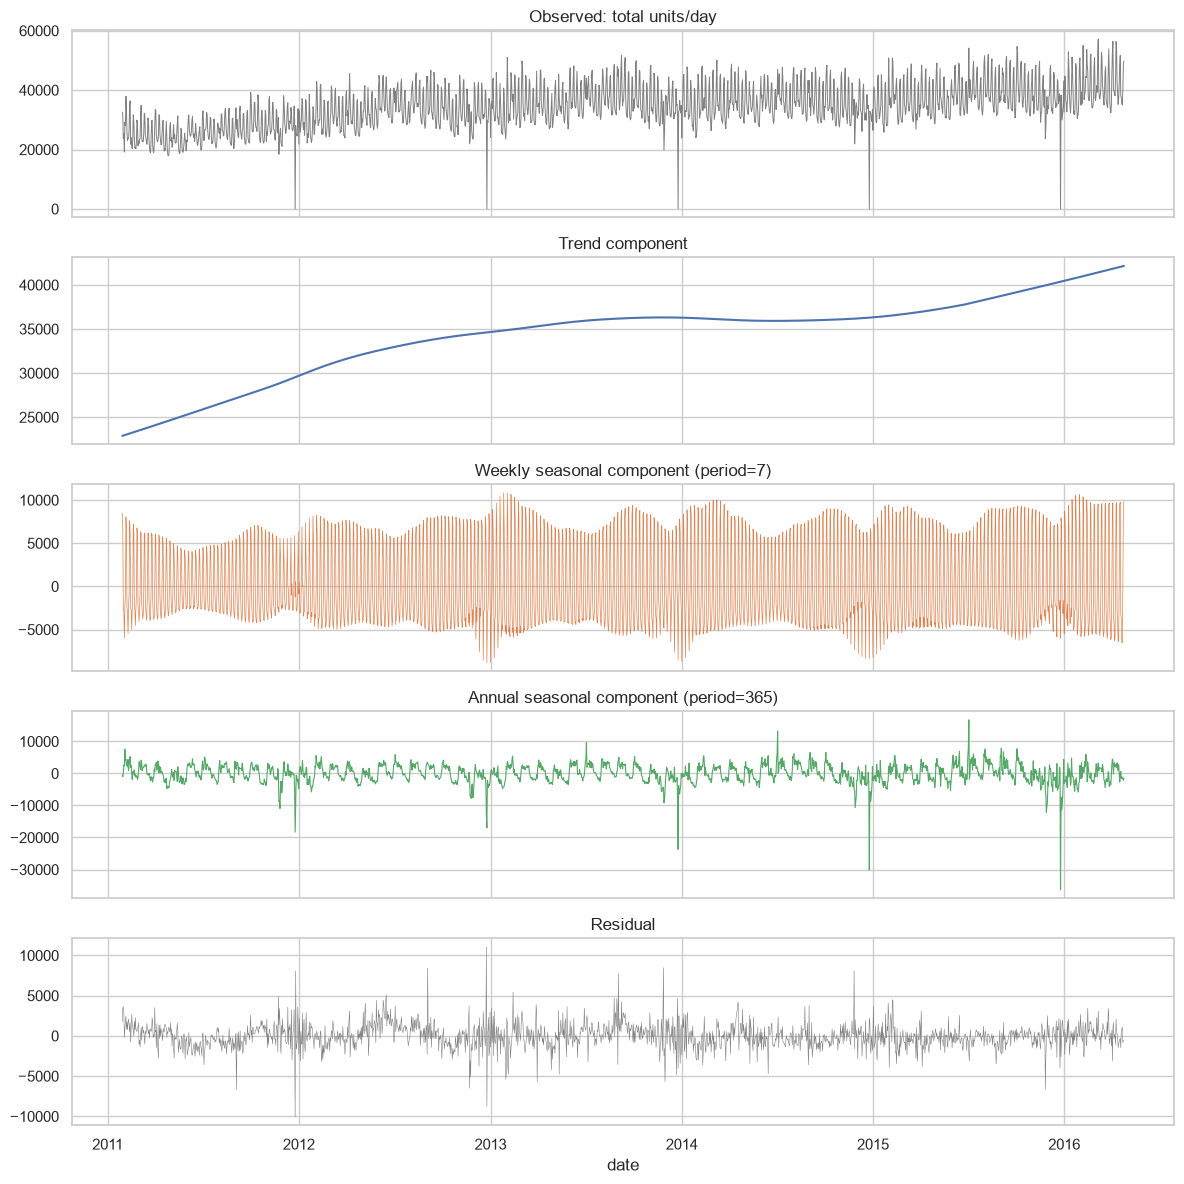

In [195]:
# ===== Figure 1: MSTL Decomposition =====
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(mstl_total.observed, color="grey", lw=0.7)
axes[0].set_title("Observed: total units/day")
axes[1].plot(mstl_total.trend, color="C0")
axes[1].set_title("Trend component")
axes[2].plot(mstl_total.seasonal["seasonal_7"], color="C1", lw=0.5)
axes[2].set_title("Weekly seasonal component (period=7)")
axes[3].plot(mstl_total.seasonal["seasonal_365"], color="C2", lw=0.8)
axes[3].set_title("Annual seasonal component (period=365)")
axes[4].plot(mstl_total.resid, color="grey", lw=0.4)
axes[4].set_title("Residual")
axes[4].set_xlabel("date")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_mstl_decomposition.png", dpi=150)
plt.show()

### Data prep: units-per-active-series growth by level

In [196]:
# Define the grouping levels to analyze
levels_config = [
    ("state_id", "by state"),
    ("store_id", "by store"),
    ("cat_id", "by category"),
    ("dept_id", "by department"),
]

# Data prep: units-per-active-series growth by level (state/store/category/department) -
# same pooled decomposition as the assortment check above, run per level to test whether
# growth is demand-driven anywhere once catalog expansion is netted out
by_level_growth = {}
for level, title in levels_config:
    level_units = sales_long.groupby(["date", level], observed=True)["sales"].sum().unstack(level)
    level_active = sales_long.groupby(["date", level], observed=True)["id"].nunique().unstack(level)
    level_ups_28d = (level_units / level_active).rolling(28, min_periods=1).mean()
    level_active_28d = level_active.rolling(28, min_periods=1).mean()

    by_level_growth[level] = pd.DataFrame({
        "units_per_series_growth": level_ups_28d.iloc[-28:].mean() / level_ups_28d.iloc[:28].mean() - 1,
        "active_series_growth": level_active_28d.iloc[-28:].mean() / level_active_28d.iloc[:28].mean() - 1,
    }).sort_values("units_per_series_growth")


### Plot: units-per-active-series growth vs active-series growth, per level

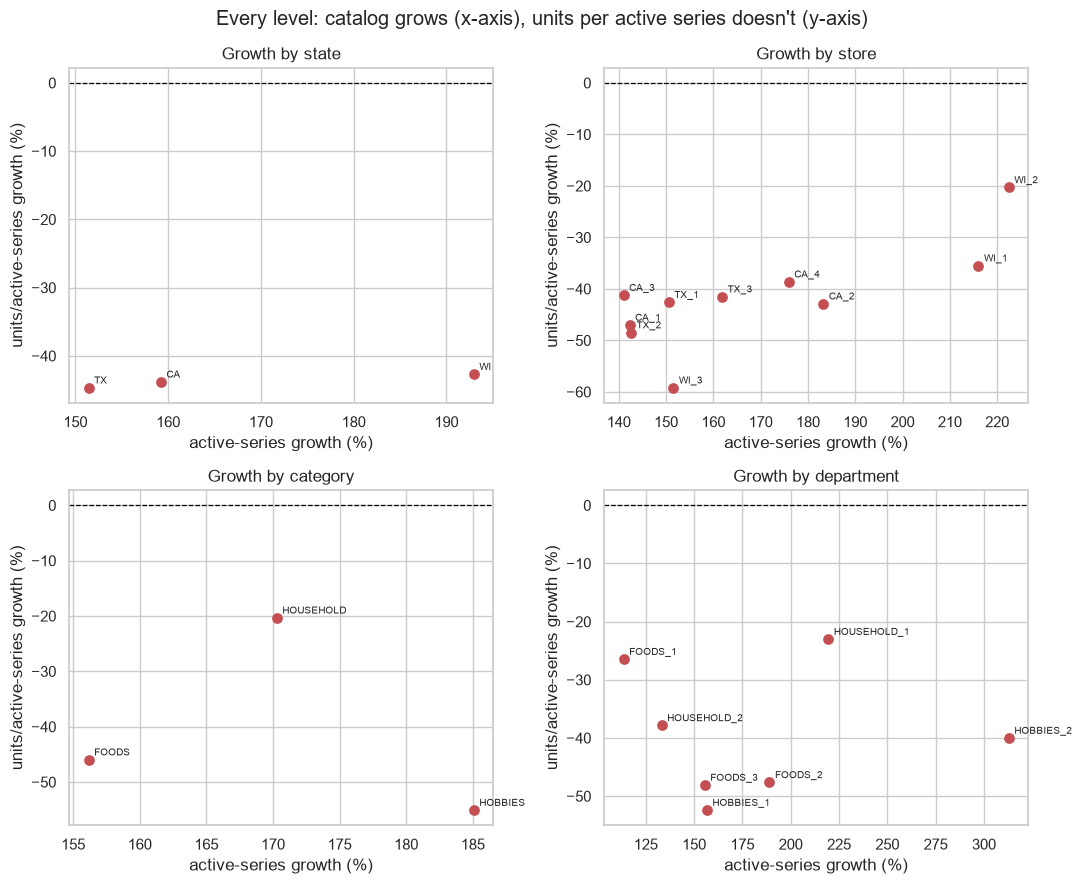

In [197]:
# Plot: units-per-active-series growth vs active-series growth, per level
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (level, title) in zip(axes.flat, levels_config):
    df = by_level_growth[level] * 100
    ax.scatter(df["active_series_growth"], df["units_per_series_growth"], s=45, color="C3", zorder=3)
    for label, row in df.iterrows():
        ax.annotate(label, (row["active_series_growth"], row["units_per_series_growth"]),
                    fontsize=7, xytext=(4, 3), textcoords="offset points")
    ax.axhline(0, color="black", lw=0.9, ls="--", zorder=1)
    ax.set_title(f"Growth {title}")
    ax.set_xlabel("active-series growth (%)")
    ax.set_ylabel("units/active-series growth (%)")

fig.suptitle("Every level: catalog grows (x-axis), units per active series doesn't (y-axis)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_by_level_growth.png", dpi=150)
plt.show()

### Assortment & Units per Series

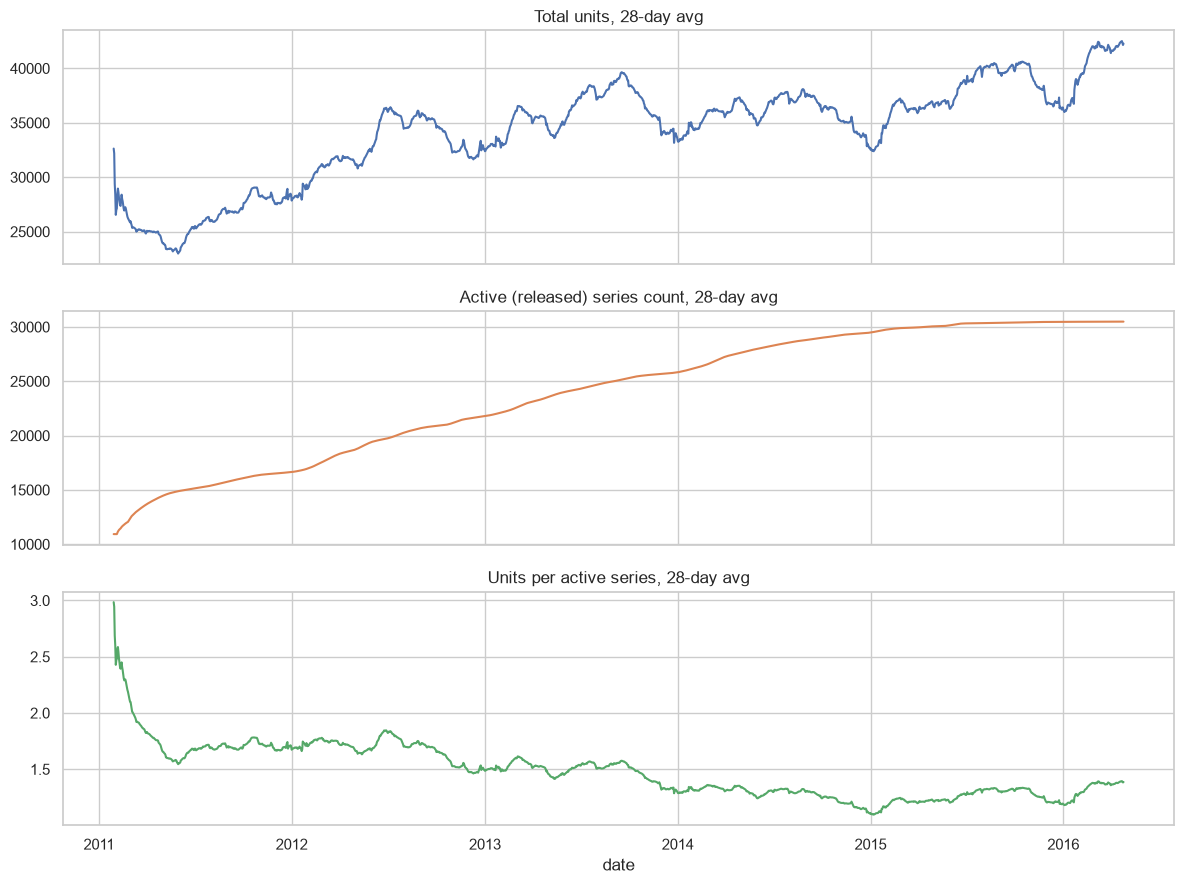

first 28d -> last 28d of training range:
  total units:          +61.1%
  active series count:  +152.9%
  units per active series: -36.7%


In [ ]:
# ===== Figure 3: Assortment & Units per Series =====
# (uses pct_change_* metrics computed in the data-prep cell above)
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(assortment_28d.index, assortment_28d["units"], color="C0")
axes[0].set_title("Total units, 28-day avg")

axes[1].plot(assortment_28d.index, assortment_28d["n_active_series"], color="C1")
axes[1].set_title("Active (released) series count, 28-day avg")

axes[2].plot(assortment_28d.index, assortment_28d["units_per_active_series"], color="C2")
axes[2].set_title("Units per active series, 28-day avg")
axes[2].set_xlabel("date")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_assortment.png", dpi=150)
plt.show()

print(f"first 28d -> last 28d of training range:")
print(f"  total units:          {pct_change_units:+.1%}")
print(f"  active series count:  {pct_change_series:+.1%}")
print(f"  units per active series: {pct_change_per_series:+.1%}")

### **Interpretation.**

The raw trend looks like strong growth — MSTL's trend rises +81.3%, total units +61.1% — but this
is **catalog expansion, not demand growth**: active series count grew +152.9% while units *per
active series* **fell -36.7%**. Each item sells less on average; the total only grows because more
items are listed.

**By-level check.** Repeating the units-per-active-series growth check (not MSTL — that is only
fit once, pooled, above) per state/store/category/department confirms this is universal, not a
few outliers skewing the pool: units-per-active-series falls at every state (-42.7% to -44.7%),
store (-20.3% to -59.2%), category (-20.3% to -55.1%), and department (-23.0% to -52.4%), while
active-series count rises 113.5%-312.8% everywhere. Cross-level differences are only in scale
(e.g. FOODS = 67.3% of units) and dilution steepness — not demand.

**Feature implication:** don't build a trend/momentum feature on raw totals, at any level (pooled,
store, or state) — it would encode catalog growth, not demand. Normalize against active-catalog
size and handle new items via release-date features (Lifecycle section) instead. Level *scale*
differences are already covered by existing categorical identity + item×store/dept×store encodings
(P5); no separate by-level trend feature needed.

## Seasonality

We run `MSTL` per category on raw daily units, then express each seasonal component as a
fraction of that category's own trend (`seasonal / trend`) - directly comparable to the "% lift"
language the hypothesis table wants, and immune to the assortment-growth confound since it's
computed against MSTL's own trend line rather than a manual units-per-active-series ratio.
MSTL's additive decomposition already isolates the seasonal components from trend, so this
division isn't detrending a second time - it rescales the already trend-free seasonal component
into a relative fraction so categories of very different absolute volume are comparable.

We keep the per-category split to test the brief's hypothesis that weekend lift differs sharply
by category (see Interpretation below - it doesn't hold up as stated).

### Data Preparation

In [199]:
# Data prep: category-level MSTL decomposition and weekly (day-of-week) seasonal effect
category_daily = (
    sales_long.groupby(["date", "cat_id"], observed=True)["sales"]
    .sum()
    .unstack("cat_id")
    .asfreq("D")
)
cat_mstl = {cat: MSTL(category_daily[cat], periods=(7, 365)).fit() for cat in category_daily.columns}

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_effect = {}
for cat, result in cat_mstl.items():
    seasonal_pct = result.seasonal["seasonal_7"] / result.trend
    dow_effect[cat] = seasonal_pct.groupby(seasonal_pct.index.day_name()).mean().reindex(weekday_order)
dow_effect_df = pd.DataFrame(dow_effect)

weekend_lift_mstl = (
    dow_effect_df.loc[["Saturday", "Sunday"]].mean()
    - dow_effect_df.loc[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]].mean()
)

### Weekly seasonal effect by day of week, per category

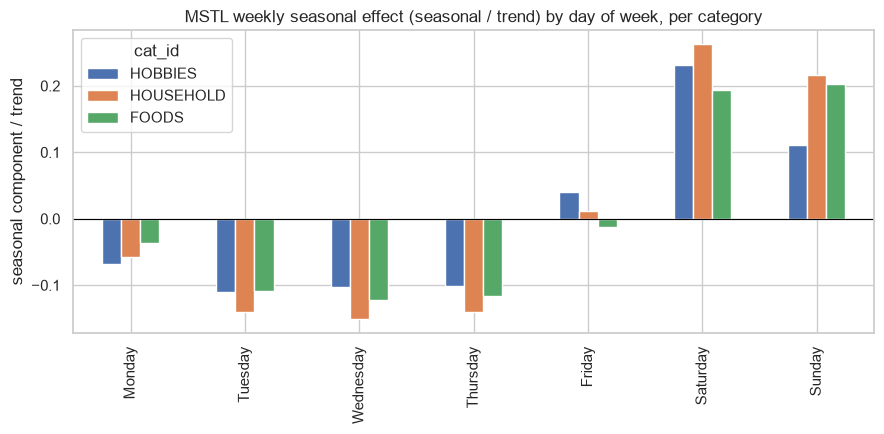

weekend seasonal effect minus weekday seasonal effect (pct points of trend):


HOUSEHOLD    0.334950
FOODS        0.276879
HOBBIES      0.239408
dtype: float64

In [200]:
# Plot: weekly seasonal effect by day of week, per category
fig, ax = plt.subplots(figsize=(9, 4.5))
dow_effect_df.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("MSTL weekly seasonal effect (seasonal / trend) by day of week, per category")
ax.set_xlabel("")
ax.set_ylabel("seasonal component / trend")
ax.legend(title="cat_id")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "seasonality_dow_mstl.png", dpi=150)
plt.show()

print("weekend seasonal effect minus weekday seasonal effect (pct points of trend):")
weekend_lift_mstl.sort_values(ascending=False)

### Annual seasonal effect (seasonal / trend) by month, per category

In [201]:
# Data prep: annual seasonal effect (seasonal / trend) by month, per category
annual_effect = {}
for cat, result in cat_mstl.items():
    seasonal_pct = result.seasonal["seasonal_365"] / result.trend
    annual_effect[cat] = seasonal_pct.groupby(seasonal_pct.index.month).mean()
annual_effect_df = pd.DataFrame(annual_effect)

peak_trough_mstl = pd.DataFrame({
    "peak_month": annual_effect_df.idxmax(),
    "trough_month": annual_effect_df.idxmin(),
    "peak_minus_trough_pct_pts": annual_effect_df.max() - annual_effect_df.min(),
})

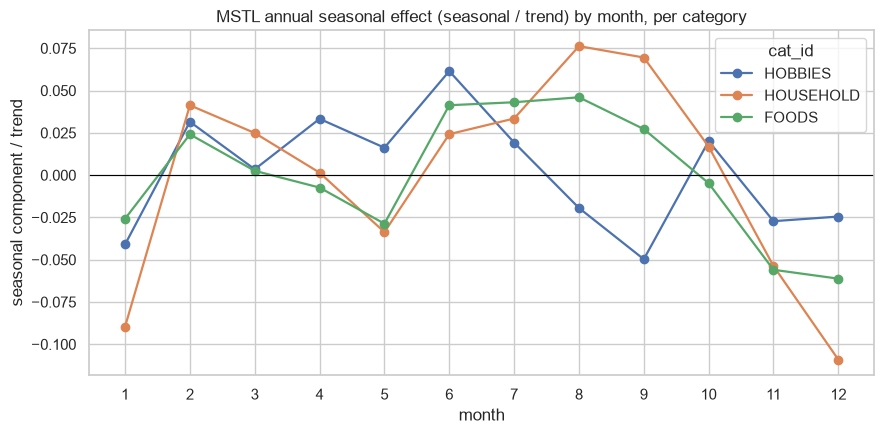

annual seasonal effect range by category:


,peak_month,trough_month,peak_minus_trough_pct_pts
HOBBIES,6,9,0.111208
HOUSEHOLD,8,12,0.185321
FOODS,8,12,0.107229


In [202]:
# Plot: annual seasonal effect by month, per category
fig, ax = plt.subplots(figsize=(9, 4.5))
annual_effect_df.plot(ax=ax, marker="o", lw=1.6)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("MSTL annual seasonal effect (seasonal / trend) by month, per category")
ax.set_xlabel("month")
ax.set_ylabel("seasonal component / trend")
ax.set_xticks(range(1, 13))
ax.legend(title="cat_id")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "seasonality_month_mstl.png", dpi=150)
plt.show()

print("annual seasonal effect range by category:")
peak_trough_mstl

### **Interpretation.**

Weekend lift is strong (+33.5/+27.7/+24.0 pct pts of trend for HOUSEHOLD/FOODS/HOBBIES) and
fairly uniform across categories. But the weekday bucket isn't uniform: Tue-Thu sit in a
genuine trough (-10 to -15 pts), while **Friday is a transition day**, near flat or positive
(+3.9/+1.2/-1.2) - closer to the weekend than to Tue-Thu. A binary `is_weekend` flag would
misclassify it.

Annually, HOUSEHOLD's swing (18.5 pts, Aug peak/Dec trough) is ~1.7x FOODS/HOBBIES (~11 each).
FOODS and HOUSEHOLD's December trough overlaps Christmas's -11.9% event-day dip (Events
section) - possibly the same effect double-counted across two components.

**Feature implication:** full 7-level `wday` categorical (already in P5), not a binary weekend
flag. For the annual pattern, don't fit one seasonal-index/harmonic curve on the pooled total
and apply it to every category - `month` and `cat_id` already interact naturally in the tree,
or add an explicit `cat_id x month` mean-encoding alongside P5's existing `cat x wday`. Resolve
the December/Christmas overlap when building Events features.

## SNAP

SNAP (food-stamp) disbursement days are state-specific — `calendar.csv` gives a separate flag per
state (`snap_CA`, `snap_TX`, `snap_WI`), and each state runs its own schedule within the month. The
brief *assumes* this is one of the highest-value features in the dataset and expects the lift to
show up in FOODS (SNAP benefits are for food purchases) — so this section checks the schedules
differ by state and quantifies the lift per state, rather than taking either as given.

To measure the lift we fit `MSTL` per state on daily FOODS units, removing the weekly and annual
cycles, then compare the residual-over-trend ratio (`resid / trend`) on SNAP vs. non-SNAP days.
Working from the residual rather than raw units keeps the states comparable despite their very
different sales volumes.

### Data Preparation

In [203]:
# Data prep: SNAP disbursement flags, first 90 days of training range
snap_schedule = (
    sales_long[["date", "snap_CA", "snap_TX", "snap_WI"]]
    .drop_duplicates("date")
    .set_index("date")
    .sort_index()
    .iloc[:90]
)

# Fixed categorical order/hues (dataviz skill palette, slots 1-3): distinguishable
# under color-vision deficiency, unlike the single-hue grayscale imshow version.
state_colors = {"CA": "#2a78d6", "TX": "#eb6834", "WI": "#1baf7a"}
row_y = {"CA": 2, "TX": 1, "WI": 0}

### SNAP Disbursement Schedule

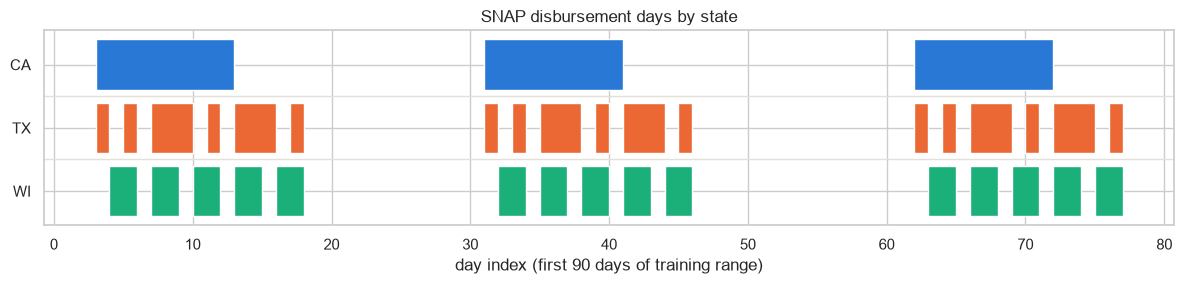

In [204]:
# Plot: SNAP disbursement schedule by state, as a timeline
fig, ax = plt.subplots(figsize=(12, 3))
for state, y in row_y.items():
    flags = snap_schedule[f"snap_{state}"].to_numpy()
    runs, start = [], None
    for i, v in enumerate(flags):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            runs.append((start, i - start))
            start = None
    if start is not None:
        runs.append((start, len(flags) - start))
    ax.broken_barh(runs, (y + 0.1, 0.8), facecolors=state_colors[state])

ax.set_yticks([y + 0.5 for y in row_y.values()])
ax.set_yticklabels(list(row_y.keys()))
for y in (1, 2):
    ax.axhline(y, color="#e1e0d9", lw=1)  # row separators, at boundaries not centers
ax.set_xlabel("day index (first 90 days of training range)")
ax.set_title("SNAP disbursement days by state")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "snap_schedule.png", dpi=150)
plt.show()

### Per-state FOODS MSTL decomposition and SNAP lift

In [3]:
# Data prep: per-state FOODS MSTL decomposition and SNAP lift (resid/trend, SNAP day vs non-SNAP day)
foods_state_daily = (
    sales_long[sales_long["cat_id"] == "FOODS"]
    .groupby(["date", "state_id"], observed=True)["sales"]
    .sum()
    .unstack("state_id")
    .asfreq("D")
)

state_mstl = {state: MSTL(foods_state_daily[state], periods=(7, 365)).fit() for state in foods_state_daily.columns}

snap_col = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}
snap_by_date = (
    sales_long[["date", "snap_CA", "snap_TX", "snap_WI"]]
    .drop_duplicates("date")
    .set_index("date")
)

snap_lift = {}
for state, result in state_mstl.items():
    resid_pct = result.resid / result.trend
    snap_flag = snap_by_date[snap_col[state]].reindex(resid_pct.index)
    # reindex([0, 1]) guarantees both keys exist (as NaN if a class is genuinely absent from this
    # window), instead of .loc[0]/.loc[1] raising KeyError if a state's flag were ever constant
    # over the aggregated slice (issue #23). Not triggered by this dataset's full training range,
    # but guards against reuse on a shorter/different window.
    grp = resid_pct.groupby(snap_flag).mean().reindex([0, 1])
    # x100: resid/trend is a raw ratio, not a percentage value - convert at the point of
    # computation so the column names are true. non_snap_effect_pct/snap_effect_pct are each a
    # plain percentage (of trend); snap_lift_pct_pts is a difference of two percentages, so it
    # stays in percentage-point units - kept as a separate suffix so the two aren't conflated.
    snap_lift[state] = {
        "non_snap_effect_pct": grp.loc[0] * 100,
        "snap_effect_pct": grp.loc[1] * 100,
        "snap_lift_pct_pts": (grp.loc[1] - grp.loc[0]) * 100,
    }
snap_lift_df = pd.DataFrame(snap_lift).T

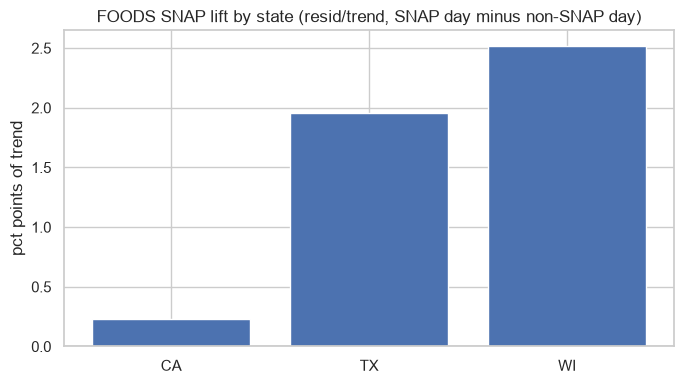

FOODS SNAP effect size by state:


,non_snap_effect_pct,snap_effect_pct,snap_lift_pct_pts
WI,-1.0%,+1.5%,+2.5 pts
TX,-0.5%,+1.5%,+2.0 pts
CA,+0.0%,+0.2%,+0.2 pts


In [4]:
# Plot: FOODS SNAP lift by state
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(snap_lift_df.index, snap_lift_df["snap_lift_pct_pts"], color="C0")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("FOODS SNAP lift by state (resid/trend, SNAP day minus non-SNAP day)")
ax.set_ylabel("pct points of trend")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "snap_lift_by_state.png", dpi=150)
plt.show()

print("FOODS SNAP effect size by state:")
snap_lift_display = snap_lift_df.sort_values("snap_lift_pct_pts", ascending=False).copy()
snap_lift_display["non_snap_effect_pct"] = snap_lift_display["non_snap_effect_pct"].map("{:+.1f}%".format)
snap_lift_display["snap_effect_pct"] = snap_lift_display["snap_effect_pct"].map("{:+.1f}%".format)
snap_lift_display["snap_lift_pct_pts"] = snap_lift_display["snap_lift_pct_pts"].map("{:+.1f} pts".format)
snap_lift_display

**Interpretation.**

The three states run genuinely different SNAP calendars (CA days 1–10; TX and WI scattered across
days 1–15), and FOODS lifts on disbursement days in all three: WI +2.5 pct pts of trend, TX +2.0,
CA +0.2. The ranking is clear; the magnitudes are not precisely identified, because SNAP days are a
fixed function of day-of-month and `MSTL(periods=(7, 365))` has no monthly component — so a generic
start-of-month effect (paycheck timing, restocking) sits in the residual alongside the SNAP effect.
CA's +0.2 in particular is small enough that we can't distinguish it from zero here.

That imprecision doesn't change the feature decision, which rests on the schedules differing by
state rather than on any effect size.

**Feature implication:** a per-state SNAP flag matched to each series' own `state_id`
(`snap_<state>`), not a single pooled `is_snap_day` — the schedules disagree often enough that
pooling would blur three different calendars into one. The model estimates the per-state magnitude
itself, so no effect size needs to be carried forward from this section.

## Events

Events are calendar-fixed (`event_name_1`/`event_type_1`; `event_name_2` marks a rare same-day
overlap — only 4 of 1913 training days — so we fold those into their `event_name_1` label rather
than double-counting a handful of dates). The brief calls out that Super Bowl, Thanksgiving,
Easter, and Christmas behave very differently from one another, so a pooled `is_event` estimate
would hide exactly the signal we need — we compute an effect size per named event, not one
aggregate number.

We reuse the total-units MSTL decomposition from the Trend section (`mstl_total`) and read off
`resid / trend` on the event day itself, the day before (lead-up), and the day after (hangover),
averaged across each event's occurrences (4-6 per event across the 5.2 years of training data —
few, but each event recurs annually on a fixed or near-fixed date, so cross-year averaging is
still a meaningful estimate, unlike averaging in a single outlier day).

**Headline events, defined.** The brief's four named events were a hypothesis to test, not a
final selection — now that the full per-event table exists, we define "headline events" as a
small set that represents each distinct behavioral pattern found in that table (see
Interpretation below), at least two events per pattern, rather than a top-magnitude-overall
ranking. See `DECISIONS.md` ("Events section — headline event selection") for why this refines
the brief's original hypothesis, and `P2-eda.md` for the note on how future phases should pick
this set.

### Data Preparation

In [5]:
# Data prep: per-event lead-up / event-day / hangover effect (resid/trend), from the Trend
# section's total-units MSTL decomposition
event_by_date = (
    sales_long[["date", "event_name_1", "event_type_1"]]
    .drop_duplicates("date")
    .set_index("date")
    .sort_index()
)
event_name = event_by_date["event_name_1"].dropna()
event_type_lookup = event_by_date["event_type_1"].dropna()

resid_pct_total = mstl_total.resid / mstl_total.trend

def phase_effect(offset_days):
    # shift each event's date by the offset, look up that day's resid/trend, then
    # relabel back onto the event name so lead-up/event/hangover align in one table
    shifted_dates = event_name.index + pd.Timedelta(days=offset_days)
    vals = resid_pct_total.reindex(shifted_dates)
    vals.index = event_name.index
    return vals.groupby(event_name, observed=True).mean()

# x100: resid/trend is a raw ratio, not a percentage - convert at the point of computation
# (same convention as the SNAP section) so column names are true and match the +11.9%-style
# language used in the Interpretation below.
event_effect_df = pd.DataFrame({
    "lead_up_pct": phase_effect(-1) * 100,
    "event_day_pct": phase_effect(0) * 100,
    "hangover_pct": phase_effect(1) * 100,
})
event_effect_df["event_type"] = event_type_lookup.groupby(event_name, observed=True).first()
event_effect_df["n_occurrences"] = event_name.value_counts()
event_effect_df = event_effect_df.sort_values("event_day_pct", key=lambda s: s.abs(), ascending=False)

### Per-event Effect Table

In [6]:
# Report: per-event effect table, sorted by |event_day| effect
print(f"named events with effect estimates: {len(event_effect_df)}")
event_effect_display = event_effect_df.copy()
for col in ["lead_up_pct", "event_day_pct", "hangover_pct"]:
    event_effect_display[col] = event_effect_display[col].map("{:+.1f}%".format)
event_effect_display

named events with effect estimates: 30


,lead_up_pct,event_day_pct,hangover_pct,event_type,n_occurrences
event_name_1,,,,,
LaborDay,-11.4%,+12.5%,-1.3%,National,5
Christmas,+6.0%,-11.9%,+6.6%,National,5
Mother's day,+3.5%,-9.3%,+1.6%,Cultural,5
Thanksgiving,+15.1%,-8.4%,-0.4%,National,5
Easter,+7.4%,-8.4%,-0.9%,Cultural,5
MemorialDay,-6.8%,+6.3%,-0.1%,National,5
SuperBowl,+4.4%,-5.2%,-2.8%,Sporting,6
PresidentsDay,-2.2%,+4.9%,-1.0%,National,6
NBAFinalsEnd,+0.1%,-4.1%,-0.1%,Sporting,5


In [6]:
# Data prep: headline events - representative examples of each behavioral pattern identified in
# the Interpretation below, not a top-magnitude-overall ranking. At least 2 events per pattern:
# dip events keep the brief's original 4 (all turned out to be dip-pattern), lift events are the
# 2 largest-|event_day| events showing the opposite (open-store) pattern, which the brief's set
# didn't include at all.
dip_events = ["Christmas", "Thanksgiving", "Easter", "SuperBowl"]
lift_events = ["LaborDay", "MemorialDay"]
phase_cols = ["lead_up_pct", "event_day_pct", "hangover_pct"]

dip_df = event_effect_df.loc[dip_events, phase_cols]
lift_df = event_effect_df.loc[lift_events, phase_cols]

### Headline Event Effect

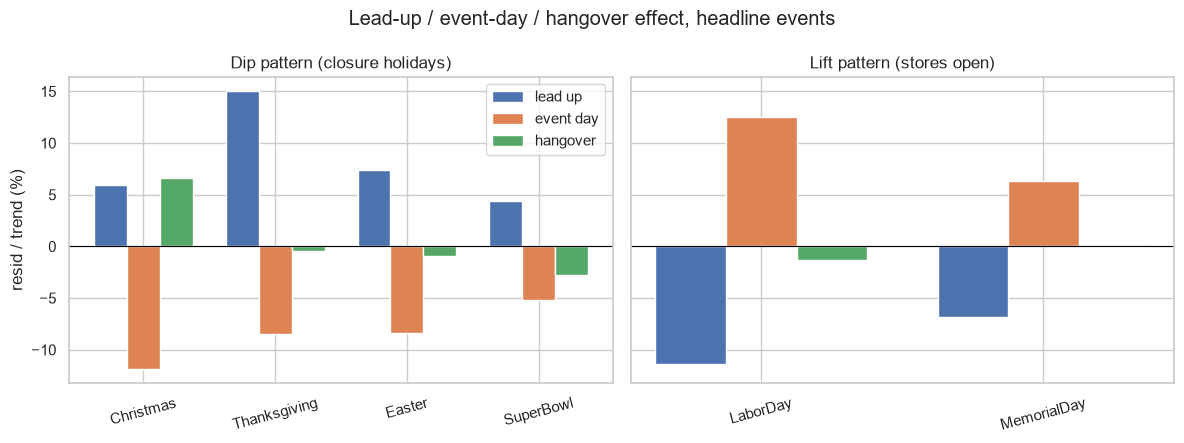

lead_up_pct event_day_pct hangover_pct
pattern event_name_1                                       
dip     Christmas          +6.0%        -11.9%        +6.6%
        Thanksgiving      +15.1%         -8.4%        -0.4%
        Easter             +7.4%         -8.4%        -0.9%
        SuperBowl          +4.4%         -5.2%        -2.8%
lift    LaborDay          -11.4%        +12.5%        -1.3%
        MemorialDay        -6.8%         +6.3%        -0.1%

In [7]:
# Plot: lead-up / event-day / hangover effect, headline events - dip pattern and lift pattern
# shown as separate panels so both behavioral patterns are visible (a single panel of only
# dip-pattern events, as before, would hide the lift pattern the Interpretation also describes)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
width = 0.25
panel_data = [(dip_df, "Dip pattern (closure holidays)"), (lift_df, "Lift pattern (stores open)")]
for ax, (df, title) in zip(axes, panel_data):
    x = np.arange(len(df))
    for i, phase in enumerate(phase_cols):
        ax.bar(x + (i - 1) * width, df[phase], width, label=phase.replace("_pct", "").replace("_", " "))
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(df.index, rotation=15)
    ax.set_title(title)
axes[0].set_ylabel("resid / trend (%)")
axes[0].legend()
fig.suptitle("Lead-up / event-day / hangover effect, headline events")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "events_headline_phases.png", dpi=150)
plt.show()

headline_display = pd.concat([dip_df, lift_df], keys=["dip", "lift"], names=["pattern", "event_name_1"]).copy()
for col in phase_cols:
    headline_display[col] = headline_display[col].map("{:+.1f}%".format)
headline_display

### Resid/Trend Mean and Std. across Event Type

In [6]:
# Data prep: event-day effect aggregated by event_type (mean absolute effect avoids dip/lift cancellation)
type_effect = event_effect_df.groupby("event_type", observed=True)["event_day_pct"].agg(
    mean_abs=lambda s: s.abs().mean(), std="std", count="count"
)
type_effect = type_effect.sort_values("mean_abs", ascending=False)


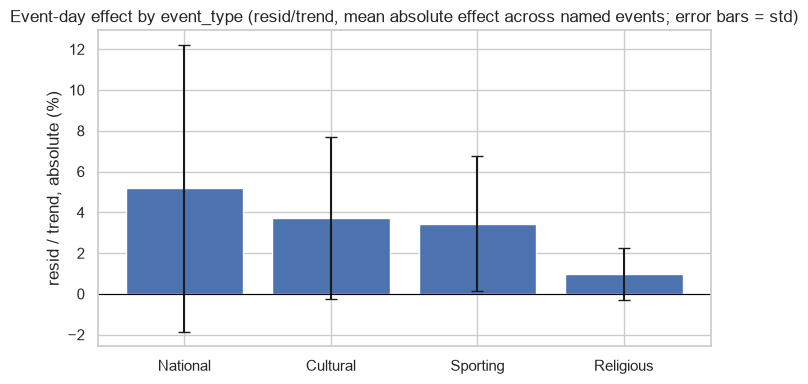

event-day effect by event_type (mean absolute effect across named events in that type):


,mean_abs,std,count
event_type,,,
National,5.1687,7.0439,10
Cultural,3.7243,3.9695,7
Sporting,3.4441,3.3215,3
Religious,0.9784,1.2914,10


In [7]:
# Plot: event-day effect by event_type
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(type_effect.index, type_effect["mean_abs"], yerr=type_effect["std"], color="C0", capsize=4)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Event-day effect by event_type (resid/trend, mean absolute effect across named events; error bars = std)")
ax.set_ylabel("resid / trend, absolute (%)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "events_by_type.png", dpi=150)
plt.show()

print("event-day effect by event_type (mean absolute effect across named events in that type):")
type_effect.round(4)


### **Interpretation.**

Two distinct patterns emerge, and they point in opposite directions — which is exactly why a
single `is_event` flag would wash out the signal:

- **Closure/gathering holidays dip on the day itself, with a lead-up lift beforehand.**
  Christmas (-11.9% event day, +6.0% lead-up), Thanksgiving (-8.4%, +15.1% lead-up — the largest
  lead-up in the table), Easter (-8.4%, +7.4% lead-up), Mother's Day (-9.3%), and Super Bowl
  (-5.2%, +4.4% lead-up) all show this shape: stock-up shopping in the day(s) before, then a
  trough on the day itself (stores closed, or people away from stores / at a gathering).
  Christmas is the only one with a large positive **hangover** too (+6.6%) — a post-holiday
  restock/return-driven rebound that Thanksgiving and Easter don't share (their hangover is near
  zero).
- **Federal holidays where stores stay open lift on the day itself.** Labor Day (+12.5%), Memorial
  Day (+6.3%), and Presidents Day (+4.9%) all show an event-day *lift*, not a dip — an extra
  shopping trip on a day off work, with no store closure to suppress it.

This is also why the `event_type` aggregate in the chart above, even measured as mean *absolute*
effect (which avoids the dip/lift cancellation a signed mean would suffer), still can't stand in
for a feature: `National` has the largest typical magnitude (5.17%) precisely because it mixes
both patterns — Christmas/Thanksgiving dipping, Labor/Memorial/Presidents Day lifting — but the
aggregate can't say which way any given National event will move sales, only that it moves a lot.
A pooled-by-type feature would still hide the real, directional effects in the dataset. `Cultural`
(3.72% mean-abs) and `Sporting` (3.44%) are smaller mainly because they're dominated by
Easter/Mother's Day and Super Bowl respectively, both of which are only moderate-sized dips;
`Religious` is genuinely the quietest type (0.98%).

**Caveat:** each event has only 4-6 occurrences in the training range, so these are noisy
point estimates, not precise effect sizes — treat them as directional (dip vs. lift, roughly which
magnitude tier) rather than exact percentages when they feed the hypothesis table.

**Feature implication:** per-`event_name` dummies (not per-`event_type`) for the events with the
largest |event_day| effect, plus explicit lead-up/hangover offset dummies for the closure-holiday
group (Christmas, Thanksgiving, Easter, Super Bowl, Mother's Day) — a single-day event flag alone
would miss the lead-up lift, which is often larger than the event-day effect itself.

## Price

`sell_price` is a weekly per-`store_id`/`item_id` price (joined onto `sales_long` via
`wm_yr_wk`). The brief asks four things: the distribution/dispersion of price, how often prices
move, sales response to a price change, and whether price *relative to an item's own history*
predicts better than the raw level.

**Two dispersion checks, answering different questions.** "Dispersion" here is deliberately split
into two separate measurements, not one: (1) *cross-store* dispersion — does the same item cost a
different amount at different stores, at a snapshot in time (the price-distribution/CV chart
below)? and (2) *within-series, over-time* dispersion — does a given item-store's own price ever
move (the change-frequency chart)? These can disagree in either direction — an item priced
identically everywhere can still reprice over the years at each store, and an item with real
regional price tiers can still be static at each individual store — so neither one substitutes for
the other. The change-frequency check is also the one the eventual price-change-recency feature
depends on, since that feature is defined along a single series' time axis, not across stores.

**No promo inference.** M5 ships no promotion flag, and we deliberately do not try to reconstruct
one from price dips. A thresholded "is this week a promo" label is just a binarized, lossy version
of the continuous price-vs-own-baseline signal we already compute below — a gradient-boosted model
can split `relative_price` at whatever cut is actually predictive, per item or in interaction with
events/SNAP, which a hand-picked threshold cannot. So price enters as a continuous sensitivity
feature, not as an inferred promo category. See `DECISIONS.md` ("Price section — promo inference
dropped").

All price-change/rolling comparisons respect invariant 2 (lag >= 28) since any such feature would
need to be computable at prediction time — we still look at same-week changes here for pure EDA
(understanding the data), but note explicitly where that would need to shift for a real feature.

### Data Preparation

In [3]:
# Data prep: price by item/store/week, and cross-store price dispersion per item
price_by_item_store = (
    sales_long[["item_id", "store_id", "cat_id", "wm_yr_wk", "sell_price"]]
    .drop_duplicates(["item_id", "store_id", "wm_yr_wk"])
)

# dispersion of the *same* item's price across stores: cv = std/mean of sell_price
# within item_id, using each item's most recent price per store to avoid time-trend noise
latest_price = (
    price_by_item_store.sort_values("wm_yr_wk")
    .groupby(["item_id", "store_id"], observed=True)
    .tail(1)
)
cross_store_cv = (
    latest_price.groupby("item_id", observed=True)["sell_price"]
    .agg(["mean", "std"])
    .assign(cv=lambda d: d["std"] / d["mean"])
    .dropna()
)

### Price distribution by category, and cross-store price Coeff. of variation (CV) per item

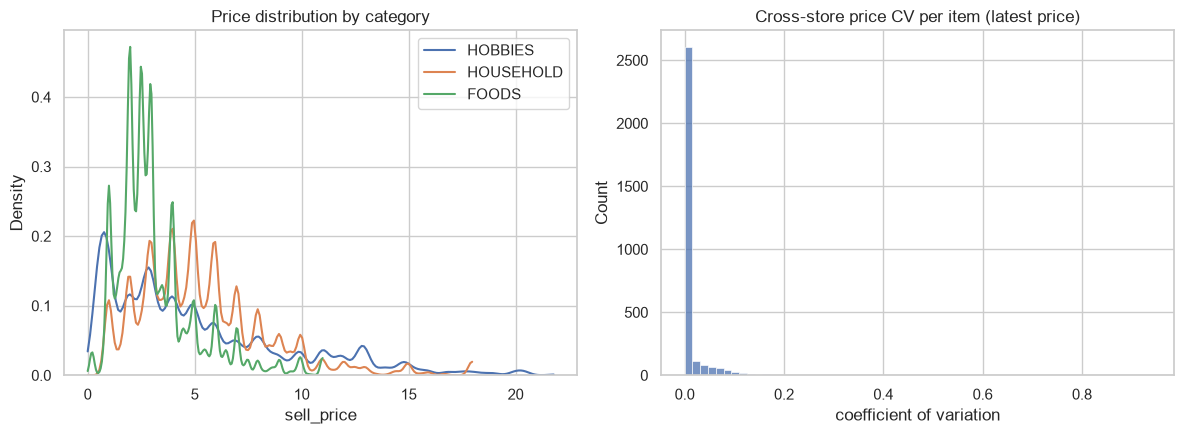

items with cross-store price CV > 0.05: 7.7%
median cross-store price CV: 0.000


,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
HOBBIES,1238705.0,5.326400,4.816673,0.01,1.97,3.97,7.47,30.98
HOUSEHOLD,2291667.0,5.465616,3.372236,0.01,2.98,4.94,6.97,107.32
FOODS,3066829.0,3.247479,2.129734,0.01,1.98,2.68,3.97,19.48


In [214]:
# Plot: price distribution by category, and cross-store price CV per item
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for cat, grp in price_by_item_store.groupby("cat_id", observed=True):
    sns.kdeplot(grp["sell_price"], ax=axes[0], label=cat, clip=(0, grp["sell_price"].quantile(0.99)))
axes[0].set_title("Price distribution by category")
axes[0].set_xlabel("sell_price")
axes[0].legend()

sns.histplot(cross_store_cv["cv"], bins=60, ax=axes[1])
axes[1].set_title("Cross-store price CV per item (latest price)")
axes[1].set_xlabel("coefficient of variation")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "price_distribution.png", dpi=150)
plt.show()

print(f"items with cross-store price CV > 0.05: {(cross_store_cv['cv'] > 0.05).mean():.1%}")
print(f"median cross-store price CV: {cross_store_cv['cv'].median():.3f}")
price_by_item_store.groupby("cat_id", observed=True)["sell_price"].describe()

In [4]:
# Data prep: weekly price series with change flags, and per-series change rate
weekly_price = (
    price_by_item_store
    .sort_values(["item_id", "store_id", "wm_yr_wk"])
    .assign(
        prev_price=lambda d: d.groupby(["item_id", "store_id"], observed=True)["sell_price"].shift(1),
        pct_change=lambda d: d["sell_price"] / d["prev_price"] - 1,
    )
)
weekly_price["changed"] = weekly_price["pct_change"].abs() > 1e-6

changes_per_series = weekly_price.groupby(["item_id", "store_id"], observed=True)["changed"].sum()
weeks_per_series = weekly_price.groupby(["item_id", "store_id"], observed=True).size()
change_rate = (changes_per_series / weeks_per_series).rename("change_rate")

### Per series fraction of price change weeks

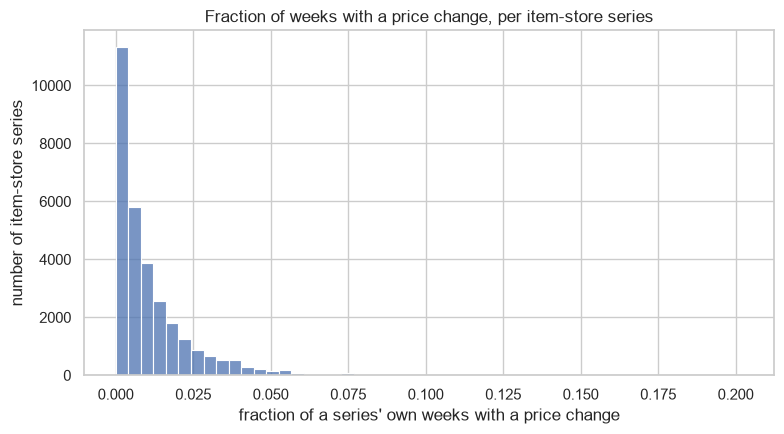

median fraction of weeks with a price change: 0.7%
series with zero price changes across training range: 27.5%
median weeks between changes (for series with >=1 change): 91.3


In [5]:
# Plot: fraction of weeks with a price change, per series
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(change_rate, bins=50, ax=ax)
ax.set_title("Fraction of weeks with a price change, per item-store series")
ax.set_xlabel("fraction of a series' own weeks with a price change")
ax.set_ylabel("number of item-store series")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "price_change_frequency.png", dpi=150)
plt.show()

print(f"median fraction of weeks with a price change: {change_rate.median():.1%}")
print(f"series with zero price changes across training range: {(changes_per_series == 0).mean():.1%}")
print(f"median weeks between changes (for series with >=1 change): "
      f"{(weeks_per_series[changes_per_series > 0] / changes_per_series[changes_per_series > 0]).median():.1f}")

### Sales response around each price-change event

In [5]:
# Data prep: sales response around each price-change event (same-week before/after comparison)
weekly_sales = (
    sales_long.groupby(["item_id", "store_id", "wm_yr_wk"], observed=True)["sales"]
    .mean()
    .rename("avg_daily_sales")
    .reset_index()
)

# prev_wm_yr_wk travels alongside prev_price in the same groupby-shift, so the "before" week
# is always the row immediately preceding the change for that item-store series, not just
# "the previous calendar week" (weeks can be sparse if items go in/out of the panel).
weekly_price["prev_wm_yr_wk"] = weekly_price.groupby(["item_id", "store_id"], observed=True)["wm_yr_wk"].shift(1)

price_change_events = weekly_price[weekly_price["changed"]][
    ["item_id", "store_id", "wm_yr_wk", "prev_wm_yr_wk", "sell_price", "prev_price", "pct_change"]
].copy()

price_change_events = price_change_events.merge(
    weekly_sales.rename(columns={"avg_daily_sales": "sales_after"}),
    on=["item_id", "store_id", "wm_yr_wk"],
    how="left",
).merge(
    weekly_sales.rename(columns={"wm_yr_wk": "prev_wm_yr_wk", "avg_daily_sales": "sales_before"}),
    on=["item_id", "store_id", "prev_wm_yr_wk"],
    how="left",
)
price_change_events["sales_pct_change"] = (
    price_change_events["sales_after"] / price_change_events["sales_before"] - 1
)
price_change_events["direction"] = np.where(price_change_events["pct_change"] < 0, "price cut", "price increase")

resp = (
    price_change_events.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["sales_pct_change"])
    .groupby("direction")["sales_pct_change"]
    .agg(["median", "mean", "count"])
)
# x100: sales_pct_change is a raw ratio, not a percentage - convert at the point of computation
# (same convention as SNAP/Events) so the plot and table show %, not a decimal that looks tiny
resp["median"] = resp["median"] * 100
resp["mean"] = resp["mean"] * 100
resp = resp.rename(columns={"median": "median_pct", "mean": "mean_pct"})

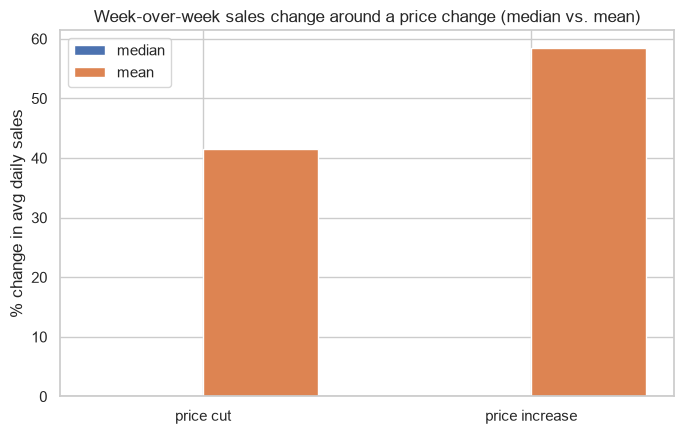

sales response to price changes, by direction:
(median == 0 for both: sparse/intermittent demand means the modal before/after pair is a tie;
 mean is shown for reference but is noise-dominated - see interpretation below)


,median_pct,mean_pct,count
direction,,,
price cut,0.0,41.515454,21246
price increase,0.0,58.480447,33538


In [6]:
# Plot: week-over-week sales change around a price change, by direction
# median is 0.0 for both directions - not a plotting bug. Events with sales_before == 0 are
# already dropped upstream (undefined ratio), so this isn't 0 -> 0 ties dominating; among the
# remaining events only 11.4% are exact before==after ties. That point mass, plus a roughly
# symmetric spread of small +/- swings around it from sparse/intermittent demand, is still
# enough to pin the 50th percentile at 0. Plot median and mean side by side so that flat result
# is visible and explained, rather than looking blank - it's what shows the mean below is
# outlier-driven, not representative of a typical event.
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(resp))
width = 0.35
# color encodes the statistic (median vs mean), not direction - direction is already on the
# x-axis via tick labels, so a second color channel for it would just fight the legend
ax.bar(x - width / 2, resp["median_pct"], width, label="median", color="C0")
ax.bar(x + width / 2, resp["mean_pct"], width, label="mean", color="C1")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(resp.index)
ax.set_ylabel("% change in avg daily sales")
ax.set_title("Week-over-week sales change around a price change (median vs. mean)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "price_change_sales_response.png", dpi=150)
plt.show()

print("sales response to price changes, by direction:")
print("(median == 0 for both: sparse/intermittent demand means the modal before/after pair is a tie;")
print(" mean is shown for reference but is noise-dominated - see interpretation below)")
resp

### Relative Price (vs. own trailing baseline, lag>=28d)

In [219]:
# Data prep: relative price (vs. own trailing baseline, lag>=28d) and sales normalized per series
# Relative price = this week's price / that series' own trailing baseline price, baseline built
# from weeks strictly before the lag-28 cutoff (>=4 weeks back) so it's computable at prediction
# time (invariant 2), unlike the same-week comparisons above which were pure EDA.
weekly_price_sorted = weekly_price.sort_values(["item_id", "store_id", "wm_yr_wk"]).copy()
grp = weekly_price_sorted.groupby(["item_id", "store_id"], observed=True)["sell_price"]
weekly_price_sorted["baseline_price"] = grp.transform(lambda s: s.shift(4).rolling(12, min_periods=4).mean())
weekly_price_sorted["relative_price"] = weekly_price_sorted["sell_price"] / weekly_price_sorted["baseline_price"]

price_sales = weekly_price_sorted.merge(weekly_sales, on=["item_id", "store_id", "wm_yr_wk"], how="inner")
price_sales = price_sales.dropna(subset=["relative_price", "sell_price", "avg_daily_sales"])

# normalize sales by each series' own mean so the comparison isn't dominated by level differences
# across series (a $1 item and a $50 item have very different sales counts but comparable pct signal)
series_mean_sales = price_sales.groupby(["item_id", "store_id"], observed=True)["avg_daily_sales"].transform("mean")
price_sales["sales_idx"] = price_sales["avg_daily_sales"] / series_mean_sales.replace(0, np.nan)
price_sales = price_sales.dropna(subset=["sales_idx"])

corr_raw_level = price_sales["sell_price"].corr(price_sales["sales_idx"], method="spearman")
corr_relative = price_sales["relative_price"].corr(price_sales["sales_idx"], method="spearman")

In [220]:
# Report: Spearman correlation, raw price vs. relative price
print("Spearman correlation with sales_idx (sales normalized by series' own mean):")
print(f"  raw sell_price:    {corr_raw_level:+.3f}")
print(f"  relative_price (price / trailing baseline, lag>=28d): {corr_relative:+.3f}")

Spearman correlation with sales_idx (sales normalized by series' own mean):
  raw sell_price:    -0.028
  relative_price (price / trailing baseline, lag>=28d): +0.024


### **Interpretation.**

Price in M5 is mostly **static, not promotional**: the median item-store series changes price in
only 0.7% of weeks, 27.5% never change at all, and among series that do change the median gap is
~91 weeks. Confirmed by the dispersion check too: 92% of items have near-identical price across
stores (cross-store CV ≈ 0), so `sell_price` mostly varies *between items*, not between stores or
over time for a given item.

The sales-response and correlation checks came back weak and counter-intuitive: mean sales after a
price *increase* was directionally larger than after a *cut* (+58% vs +42%), and both raw and
relative-to-baseline price showed near-zero Spearman correlation with sales (-0.028, +0.024). This
is a trend confound, not real elasticity: price changes are rare and not evenly spread across the
training range, and the Trend section already showed strong growth over it (+81.3% raw,
+152.9% active-series). If price increases skew later in the range on average — plausible, since
repricing tends to drift upward over time rather than randomly — then "sales after an increase"
partly just samples a later, higher-baseline period, not a response to the price move. The median
being 0.0% for both directions (Price section, code comment) confirms the mean is driven by a
handful of large-swing events, not a typical response — exactly what a pooled, uncontrolled
comparison like this can't be trusted to measure. A real elasticity estimate needs item-level
regression with trend/seasonality/event controls, out of scope for EDA.

**Feature implication:**
- A price-change-**recency** feature (weeks since this series last repriced). This is distinct from
  the price *level* features below: with 27.5% of series never repricing and a ~91-week median gap,
  a reprice is closer to a rare structural break than a routine covariate, and "how stale is this
  price" is information the level alone doesn't carry.
- Feed `relative_price` (price / own trailing baseline, lag >=28) to the model as a **continuous**
  feature. The near-zero Spearman above rejects a *pooled scalar elasticity coefficient*, not price
  as an input — Spearman only sees pooled monotonic response, while a GBM can learn per-item,
  non-monotonic, and price x event/SNAP interaction effects it cannot.
- Do **not** binarize price into an inferred "promo" flag. M5 has no promotion label, and a
  thresholded price-dip proxy is strictly lossy against the continuous feature above while
  hardcoding an arbitrary cut the model would otherwise learn.

## Intermittency

Each series here is `id` (`item_id` x `store_id`). Because P1 already dropped pre-release rows,
a series' row count in `sales_long` is its own observed length, not the full 1913-day training
window — so ADI is computed against each series' own period count, not a shared denominator.

- **ADI** (average inter-demand interval) = observed periods / non-zero periods. Higher ADI means
  demand is sparser (longer average gaps between sales).
- **CV²** (squared coefficient of variation of non-zero demand) = `(std(nonzero) / mean(nonzero))^2`.
  Higher CV² means non-zero demand is more erratic in size.
- Standard cutoffs (Syntetos-Boylan): ADI = 1.32, CV² = 0.49, giving four quadrants: smooth,
  erratic, intermittent, lumpy.

Series with only one non-zero observation have an undefined sample std (`ddof=1` needs >=2 points);
we treat CV² as 0 for those (no variability observed yet, not "no variability exists") and flag the
count separately rather than silently dropping them.

In [223]:
# Data prep: per-series zero-sales fraction, over each series' own observed history
sales_long["is_nonzero"] = sales_long["sales"] > 0

series_counts = sales_long.groupby("id", observed=True).agg(
    n_periods=("sales", "size"),
    n_nonzero=("is_nonzero", "sum"),
)
zero_frac = (1 - series_counts["n_nonzero"] / series_counts["n_periods"]).rename("zero_fraction")

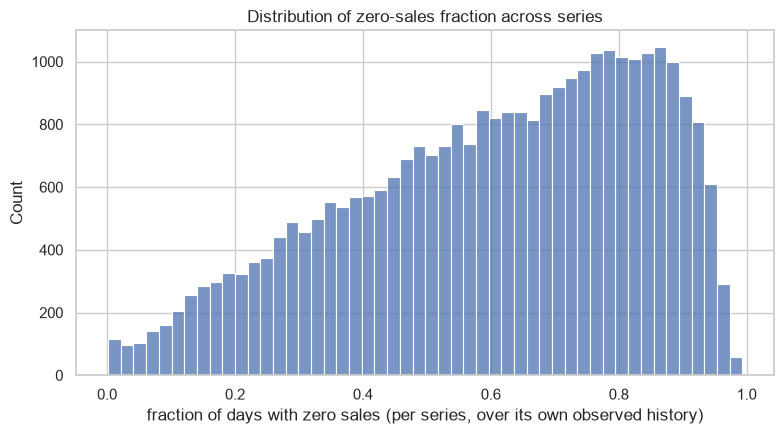

series (id count): 30,490
median zero-sales fraction: 63.5%
series with >=50% zero-sales days: 67.6%
series with >=90% zero-sales days: 7.8%


In [224]:
# Plot: distribution of zero-sales fraction across series
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(zero_frac, bins=50, ax=ax)
ax.set_title("Distribution of zero-sales fraction across series")
ax.set_xlabel("fraction of days with zero sales (per series, over its own observed history)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "intermittency_zero_fraction.png", dpi=150)
plt.show()

print(f"series (id count): {len(series_counts):,}")
print(f"median zero-sales fraction: {zero_frac.median():.1%}")
print(f"series with >=50% zero-sales days: {(zero_frac >= 0.5).mean():.1%}")
print(f"series with >=90% zero-sales days: {(zero_frac >= 0.9).mean():.1%}")

In [225]:
# Data prep: ADI / CV2 per series and quadrant classification (Syntetos-Boylan cutoffs)
nonzero_stats = (
    sales_long.loc[sales_long["is_nonzero"], ["id", "sales"]]
    .groupby("id", observed=True)["sales"]
    .agg(mean_nonzero="mean", std_nonzero="std", n_nonzero_check="size")
)

series_stats = series_counts.join(nonzero_stats)
# n_nonzero_check comes from a groupby that only sees series with >=1 non-zero day, so an
# all-zero series is absent from that groupby and joins as NaN here, not 0 - fillna(0) before
# comparing so the assert doesn't crash on a (currently nonexistent, but possible) all-zero
# series (issue #22).
assert (series_stats["n_nonzero"] == series_stats["n_nonzero_check"].fillna(0)).all(), \
    "nonzero count mismatch between the two aggregation passes"
series_stats = series_stats.drop(columns=["n_nonzero_check"])

n_all_zero = series_stats["n_nonzero"].eq(0).sum()
n_single_nonzero = series_stats["n_nonzero"].eq(1).sum()

series_stats["adi"] = series_stats["n_periods"] / series_stats["n_nonzero"]
series_stats["cv2"] = (series_stats["std_nonzero"] / series_stats["mean_nonzero"]) ** 2
series_stats["cv2"] = series_stats["cv2"].fillna(0.0)

ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49

conditions = [
    (series_stats["adi"] < ADI_CUTOFF) & (series_stats["cv2"] < CV2_CUTOFF),
    (series_stats["adi"] < ADI_CUTOFF) & (series_stats["cv2"] >= CV2_CUTOFF),
    (series_stats["adi"] >= ADI_CUTOFF) & (series_stats["cv2"] < CV2_CUTOFF),
]
choices = ["smooth", "erratic", "intermittent"]
series_stats["quadrant"] = np.select(conditions, choices, default="lumpy")
series_stats["quadrant"] = series_stats["quadrant"].astype("category")

quadrant_counts = series_stats["quadrant"].value_counts()
quadrant_pct = (quadrant_counts / len(series_stats) * 100).round(1)

series with zero non-zero days (all-zero over training range): 0
series with exactly one non-zero day (std undefined, cv2 set to 0): 0


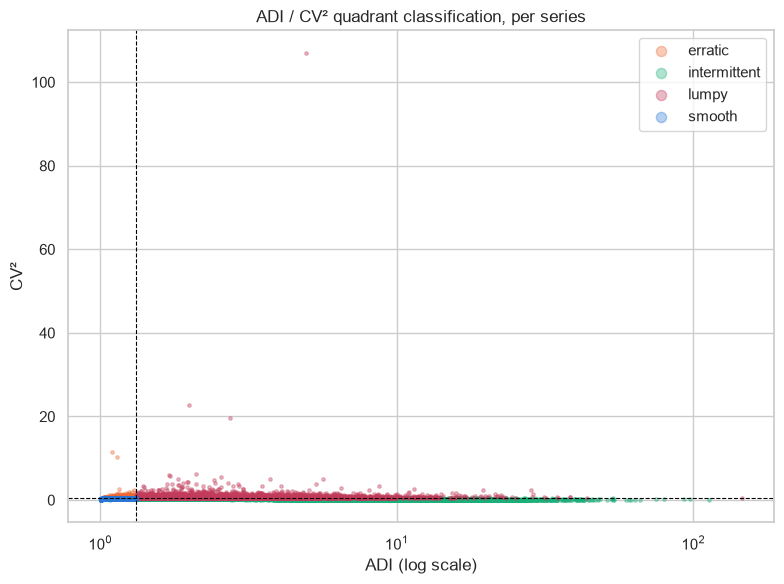

quadrant counts:


,count,pct
quadrant,,
intermittent,22159,72.7
lumpy,5612,18.4
smooth,1874,6.1
erratic,845,2.8


In [226]:
# Plot: ADI / CV2 quadrant classification, per series
print(f"series with zero non-zero days (all-zero over training range): {n_all_zero}")
print(f"series with exactly one non-zero day (std undefined, cv2 set to 0): {n_single_nonzero}")

fig, ax = plt.subplots(figsize=(8, 6))
palette = {"smooth": "#2a78d6", "erratic": "#eb6834", "intermittent": "#1baf7a", "lumpy": "#c23b5a"}
for q, grp in series_stats.groupby("quadrant", observed=True):
    ax.scatter(grp["adi"], grp["cv2"], s=6, alpha=0.35, label=q, color=palette[q])
ax.axvline(ADI_CUTOFF, color="black", lw=0.8, ls="--")
ax.axhline(CV2_CUTOFF, color="black", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_xlabel("ADI (log scale)")
ax.set_ylabel("CV²")
ax.set_title("ADI / CV² quadrant classification, per series")
ax.legend(markerscale=3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "intermittency_adi_cv2_quadrants.png", dpi=150)
plt.show()

print("quadrant counts:")
pd.DataFrame({"count": quadrant_counts, "pct": quadrant_pct})

In [227]:
# Data prep: cap all-zero-series ADI at n_periods, then build the final segments table
# All-zero series (n_nonzero == 0) would give adi = inf (n_periods / 0); cap adi at n_periods
# instead (the longest possible inter-demand interval given the observed window) so the value is
# finite and the row is still persisted, rather than silently dropping series that never sold.
series_stats["adi"] = series_stats["adi"].replace(np.inf, np.nan)
series_stats["adi"] = series_stats["adi"].fillna(series_stats["n_periods"])

segments = (
    series_stats
    .reset_index()[["id", "adi", "cv2", "quadrant"]]
    .astype({"adi": "float32", "cv2": "float32", "quadrant": "category"})
)

assert segments["id"].is_unique, "expected exactly one row per series id"
assert not segments["adi"].isna().any() and not segments["cv2"].isna().any(), \
    "adi/cv2 should be fully populated after the all-zero-series fix above"

In [228]:
# Report: persist series_segments.parquet
segments.to_parquet(PROCESSED_DIR / "series_segments.parquet", index=False)

print(f"persisted {len(segments):,} rows to {PROCESSED_DIR / 'series_segments.parquet'}")
segments.dtypes

persisted 30,490 rows to ..\data\processed\series_segments.parquet


id          category
adi          float32
cv2          float32
quadrant    category
dtype: object

**Interpretation.**

This dataset is dominated by sparse demand: the median series has zero sales on 63.5% of its
observed days, and two-thirds of series (67.6%) are zero on at least half their days. Only 7.8%
are extremely sparse (>=90% zero days), so the bulk of the mass is "regularly intermittent" rather
than "almost never sells."

The ADI/CV² quadrant split confirms this at the classification level: **72.7% of series land in
`intermittent`** (sparse but not erratic in size), 18.4% are `lumpy` (sparse *and* erratic —
the hardest quadrant to forecast, since both timing and magnitude are unpredictable), and only
6.1% are `smooth` (frequent, regular demand — where standard point-forecast methods work best).
`erratic` (frequent but size-variable) is the smallest group at 2.8%. No series were all-zero or
single-occurrence over the training range, so the edge-case handling above didn't end up mattering
for this dataset, though it's still correct to have it.

**Feature implication:** the `smooth`/`erratic`/`intermittent`/`lumpy` label in
`series_segments.parquet` should drive model routing in P6/P7 — with ~91% of series in the two
"sparse" quadrants (`intermittent` + `lumpy`), a single point-forecast model tuned on the
aggregate would be optimizing mostly for the minority `smooth` behavior. `lumpy` series in
particular (18.4%, the least forecastable quadrant) may warrant a distinct treatment (e.g.
probabilistic/zero-inflated methods) rather than being pooled with `intermittent`.

## Lifecycle

Release day per series = `min(d)` in `sales_long` (P1 already dropped pre-release rows, so this is
exact, not inferred). Before assuming anything about items "dying" partway through the panel, we
checked directly: **every one of the 30,490 series has rows through exactly `d_1913`** — nothing
drops out of the panel once released. So "dies mid-panel" isn't observable as a row-count / panel-
exit phenomenon in this dataset; the only way an item can look "dead" is a long trailing run of
zero-sales days while it's still structurally present. We check for that instead.

In [229]:
# Data prep: release day per series (min(d) in sales_long, exact since P1 already dropped
# pre-release rows), joined with category
release_day = sales_long.groupby("id", observed=True)["d"].min().rename("release_day")
release_cat = (
    sales_long[["id", "cat_id"]]
    .drop_duplicates("id")
    .set_index("id")["cat_id"]
)
release_df = release_day.to_frame().join(release_cat)

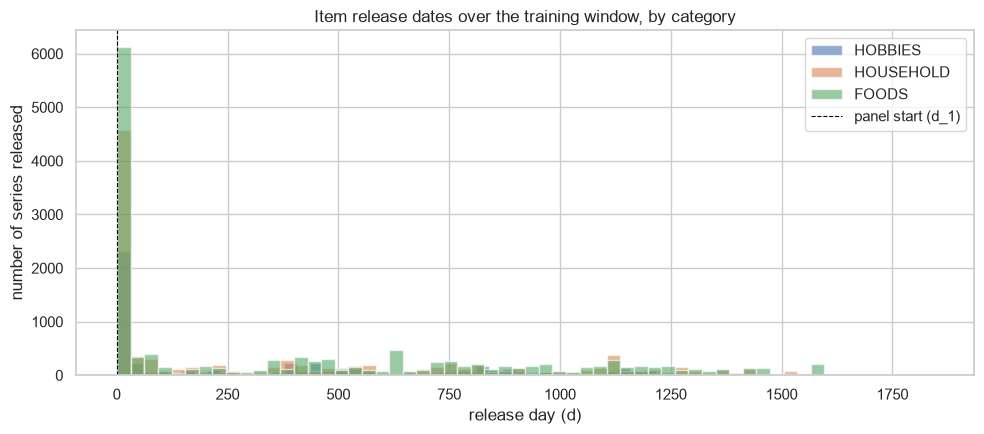

series present from d_1 (panel start): 10,932 (35.9%)
series released after d_1 ("new" items joining mid-panel): 19,558 (64.1%)


,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
HOBBIES,5650.0,384.321239,437.311090,1.0,1.0,211.0,757.0,1737.0
HOUSEHOLD,10470.0,386.844413,470.232440,1.0,1.0,92.0,750.0,1842.0
FOODS,14370.0,425.067989,493.635915,1.0,1.0,190.0,785.0,1842.0


In [230]:
# Plot: item release dates over the training window, by category
fig, ax = plt.subplots(figsize=(10, 4.5))
for cat, grp in release_df.groupby("cat_id", observed=True):
    ax.hist(grp["release_day"], bins=60, alpha=0.6, label=cat)
ax.axvline(1, color="black", lw=0.8, ls="--", label="panel start (d_1)")
ax.set_xlabel("release day (d)")
ax.set_ylabel("number of series released")
ax.set_title("Item release dates over the training window, by category")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lifecycle_release_dates.png", dpi=150)
plt.show()

n_at_panel_start = (release_df["release_day"] == 1).sum()
print(f"series present from d_1 (panel start): {n_at_panel_start:,} ({n_at_panel_start / len(release_df):.1%})")
print(f"series released after d_1 (\"new\" items joining mid-panel): "
      f"{(release_df['release_day'] > 1).sum():,} ({(release_df['release_day'] > 1).mean():.1%})")
release_df.groupby("cat_id", observed=True)["release_day"].describe()

In [231]:
# Data prep: trailing zero-sales run length per series, as of the end of the training range
TRAIN_LAST_DAY = 1913

last_nonzero_day = (
    sales_long.loc[sales_long["sales"] > 0]
    .groupby("id", observed=True)["d"]
    .max()
    .rename("last_nonzero_day")
)

lifecycle_df = release_df.join(last_nonzero_day)
# no all-zero series exist (confirmed in the Intermittency section), but guard anyway: an
# all-zero series would have no last_nonzero_day, so its "dormant" tail is its whole history.
lifecycle_df["last_nonzero_day"] = lifecycle_df["last_nonzero_day"].fillna(lifecycle_df["release_day"] - 1)
lifecycle_df["trailing_zero_days"] = TRAIN_LAST_DAY - lifecycle_df["last_nonzero_day"]

DORMANT_CUTOFF = 180  # ~6 months with zero sales, still structurally in the panel

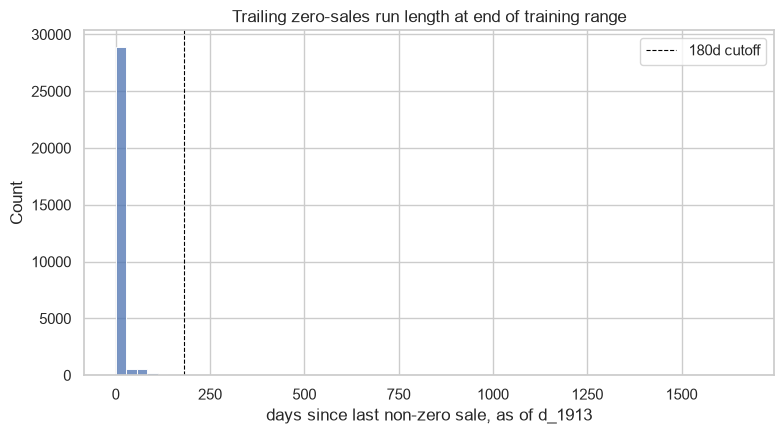

series with >=180d of trailing zero sales as of d_1913 ("functionally discontinued" but still in the panel): 173 (0.6%)
series with a sale in the final 28 days (d_1886-d_1913): 94.8%


In [232]:
# Plot: trailing zero-sales run length at end of training range
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(lifecycle_df["trailing_zero_days"], bins=60, ax=ax)
ax.axvline(DORMANT_CUTOFF, color="black", lw=0.8, ls="--", label=f"{DORMANT_CUTOFF}d cutoff")
ax.set_xlabel("days since last non-zero sale, as of d_1913")
ax.set_title("Trailing zero-sales run length at end of training range")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lifecycle_trailing_zero_run.png", dpi=150)
plt.show()

n_dormant = (lifecycle_df["trailing_zero_days"] >= DORMANT_CUTOFF).sum()
print(f"series with >={DORMANT_CUTOFF}d of trailing zero sales as of d_1913 "
      f"(\"functionally discontinued\" but still in the panel): {n_dormant:,} "
      f"({n_dormant / len(lifecycle_df):.1%})")
print(f"series with a sale in the final 28 days (d_1886-d_1913): "
      f"{(lifecycle_df['trailing_zero_days'] < 28).mean():.1%}")

In [233]:
# Data prep: available history length per series, as of the end of the training range
lifecycle_df["history_days"] = TRAIN_LAST_DAY - lifecycle_df["release_day"] + 1

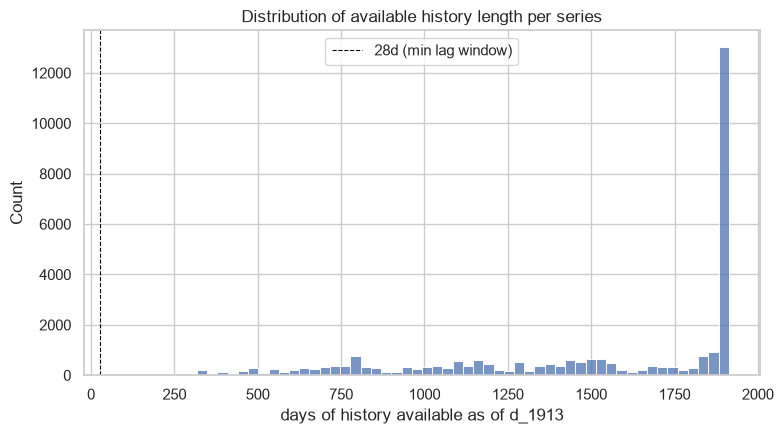

series with <28 days of history (no lag-28+ feature is computable at all, invariant 2): 0 (0.00%)
series with <90 days of history: 11 (0.04%)
series with <365 days of history: 415 (1.36%)


In [234]:
# Plot: distribution of available history length per series
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(lifecycle_df["history_days"], bins=60, ax=ax)
ax.axvline(28, color="black", lw=0.8, ls="--", label="28d (min lag window)")
ax.set_xlabel("days of history available as of d_1913")
ax.set_title("Distribution of available history length per series")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lifecycle_history_length.png", dpi=150)
plt.show()

print(f"series with <28 days of history (no lag-28+ feature is computable at all, invariant 2): "
      f"{(lifecycle_df['history_days'] < 28).sum():,} ({(lifecycle_df['history_days'] < 28).mean():.2%})")
print(f"series with <90 days of history: "
      f"{(lifecycle_df['history_days'] < 90).sum():,} ({(lifecycle_df['history_days'] < 90).mean():.2%})")
print(f"series with <365 days of history: "
      f"{(lifecycle_df['history_days'] < 365).sum():,} ({(lifecycle_df['history_days'] < 365).mean():.2%})")

**Interpretation.**

Only 35.9% of series were present at panel start (`d_1`); the other 64.1% joined mid-panel,
matching the assortment-growth story from the Trend section (active series +152.9% over the
training window) - this wasn't a handful of new SKUs, it's the majority of the catalog arriving
after the panel began. Release dates skew fairly even across categories rather than clustering
in one launch wave (median release day 92-211 depending on category), so this looks like ongoing
gradual assortment expansion, not a small number of large batch launches.

The "dies mid-panel" question resolved cleanly: since no series ever drops out of `sales_long`
(confirmed above), only **0.6% of series (173)** show a long dormant tail (>=180 days with zero
sales heading into `d_1913`), and 94.8% of series had at least one sale in the final 28 days. So
discontinuation, to the extent it exists in this window, is rare - most of the catalog is still
actively selling as training ends.

Cold-start is a non-issue at the invariant-2 boundary specifically: **zero series have less than
28 days of history**, so every series can support a lag-28 feature by construction (P1's release
trimming plus the training window length guarantees this). It only becomes a real practical
concern further out - 1.36% of series (415) have under a year of history, which matters for any
feature relying on the annual seasonal component (MSTL's `period=365`, used throughout this
notebook) rather than the lag features themselves.

**Feature implication:**
- A `days_since_release` (or `history_days`) feature is worth carrying - it's cheap, always
  defined, and flags the ~1.4% of series where annual-seasonality-based features are unreliable
  due to short history.
- The 173 dormant series (0.6%) are too small a group to need a dedicated "discontinued" model
  path, but a `days_since_last_sale` feature would let a single model down-weight or flag them
  naturally rather than needing separate routing (unlike the intermittency quadrants, which are
  large enough groups to justify routing).
- No cold-start exception is needed for lag-28+ features themselves - invariant 2's lag window is
  satisfied for every series in this dataset.

## Outliers

We flag extreme single-day spikes per series using a **per-series IQR fence on non-zero sales
days** (`Q1`/`Q3` computed only from days the series actually sold, since zero-inflation would
otherwise collapse the quartiles toward 0): `upper_fence = Q3 + 1.5 * (Q3 - Q1)`, spike =
`sales > upper_fence`. IQR was chosen over a MAD-based z-score: a z-score's "how many deviations
away" interpretation leans on a roughly-symmetric, near-normal shape, while non-zero demand here
is often right-skewed (occasional large multiples of the typical sale is exactly the phenomenon
being investigated) - IQR is quantile-based and doesn't carry that assumption.

To distinguish genuine promotional demand from unexplained (and potentially implausible) spikes,
each flagged day is cross-checked against three signals already computed earlier in this
notebook: a price drop (`relative_price < 0.90`, from the Price section), a named event day, and
a SNAP day (matched to the row's own `state_id`). A spike that coincides with one of these has a
known demand driver; one that doesn't is "unexplained" by the signals available in this dataset -
not necessarily wrong, just unaccounted for by what we can check.

In [235]:
# Data prep: per-series IQR fence on non-zero sales days, and spike flag on sales_long
nonzero_sales = sales_long.loc[sales_long["sales"] > 0, ["id", "sales"]]
q1 = nonzero_sales.groupby("id", observed=True)["sales"].quantile(0.25).rename("q1")
q3 = nonzero_sales.groupby("id", observed=True)["sales"].quantile(0.75).rename("q3")
fence_df = pd.concat([q1, q3], axis=1)
fence_df["iqr"] = fence_df["q3"] - fence_df["q1"]
fence_df["upper_fence"] = (fence_df["q3"] + 1.5 * fence_df["iqr"]).astype("float32")

sales_long = sales_long.merge(fence_df[["upper_fence"]], on="id", how="left")
sales_long["is_spike"] = sales_long["sales"] > sales_long["upper_fence"]

n_spike_days = sales_long["is_spike"].sum()
n_series_with_spike = sales_long.loc[sales_long["is_spike"], "id"].nunique()

In [236]:
# Report: overall spike-day counts
print(f"spike days: {n_spike_days:,} ({n_spike_days / len(sales_long):.3%} of all rows)")
print(f"series with >=1 spike day: {n_series_with_spike:,} "
      f"({n_series_with_spike / sales_long['id'].nunique():.1%} of all series)")

spike days: 1,008,763 (2.192% of all rows)
series with >=1 spike day: 30,318 (99.4% of all series)


In [237]:
# Data prep: cross-check each spike day against known demand drivers (price drop, event, SNAP)
spike_days = sales_long.loc[sales_long["is_spike"], [
    "id", "item_id", "store_id", "state_id", "date", "wm_yr_wk", "sales", "upper_fence",
    "event_name_1", "snap_CA", "snap_TX", "snap_WI",
]].copy()

# reuse the Price section's relative-price signal (item_id/store_id/wm_yr_wk grain)
spike_days = spike_days.merge(
    weekly_price_sorted[["item_id", "store_id", "wm_yr_wk", "relative_price"]],
    on=["item_id", "store_id", "wm_yr_wk"], how="left",
)
spike_days["is_price_drop"] = spike_days["relative_price"] < 0.90
spike_days["is_event"] = spike_days["event_name_1"].notna()

# Vectorized state -> own-state SNAP flag lookup (issue #24): index the snap_CA/TX/WI matrix by
# each row's state_id column position, instead of a Python-level row-wise .apply over ~1M rows.
snap_state_cols = ["snap_CA", "snap_TX", "snap_WI"]
snap_matrix = spike_days[snap_state_cols].to_numpy()
state_col_idx = spike_days["state_id"].map({"CA": 0, "TX": 1, "WI": 2}).to_numpy()
spike_days["is_snap"] = snap_matrix[np.arange(len(spike_days)), state_col_idx] == 1

spike_days["explained"] = (
    spike_days["is_price_drop"].fillna(False) | spike_days["is_event"] | spike_days["is_snap"]
)
spike_days["magnitude"] = spike_days["sales"] / spike_days["upper_fence"]

driver_counts = pd.Series({
    "price drop": spike_days["is_price_drop"].sum(),
    "event": spike_days["is_event"].sum(),
    "SNAP": spike_days["is_snap"].sum(),
    "unexplained": (~spike_days["explained"]).sum(),
})

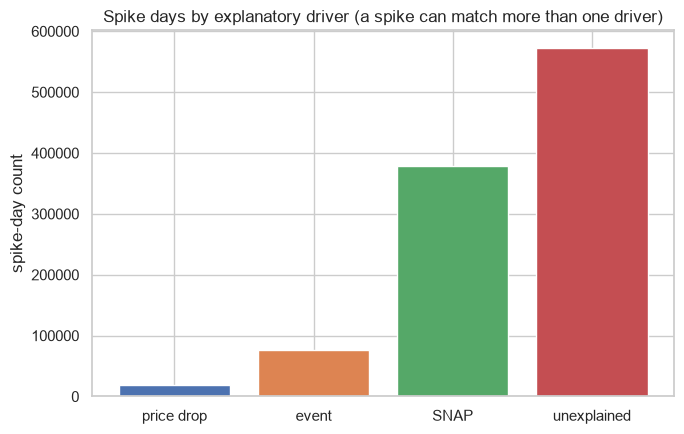


explained: 436,081 (43.2%)
unexplained: 572,682 (56.8%)


price drop      18500
event           76817
SNAP           378445
unexplained    572682
dtype: int64

In [238]:
# Plot: spike days by explanatory driver
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(driver_counts.index, driver_counts.values, color=["C0", "C1", "C2", "C3"])
ax.set_title("Spike days by explanatory driver (a spike can match more than one driver)")
ax.set_ylabel("spike-day count")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "outliers_spike_drivers.png", dpi=150)
plt.show()

print(f"\nexplained: {spike_days['explained'].sum():,} ({spike_days['explained'].mean():.1%})")
print(f"unexplained: {(~spike_days['explained']).sum():,} ({(~spike_days['explained']).mean():.1%})")
driver_counts

magnitude > 5x fence: 3,329 days (0.330% of spikes, 0.0072% of all rows)
magnitude > 10x fence: 274 days (0.027% of spikes, 0.0006% of all rows)
magnitude > 20x fence: 28 days (0.003% of spikes, 0.0001% of all rows)
magnitude > 50x fence: 4 days (0.000% of spikes, 0.0000% of all rows)

series with any spike >10x fence: 193 (0.63% of all series)


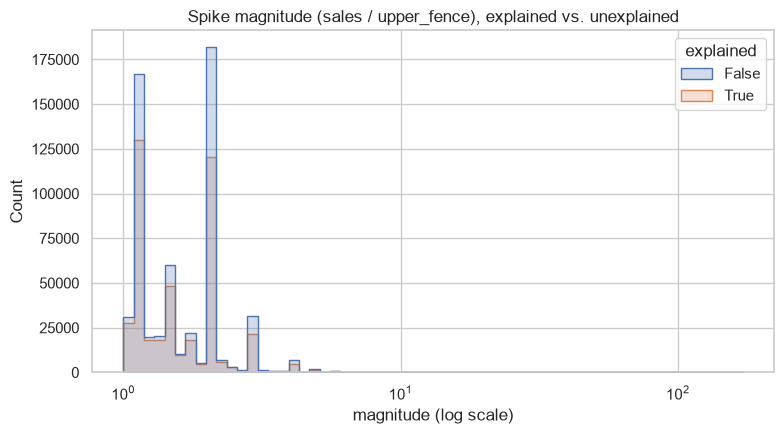


top 10 most extreme spikes:


,id,date,sales,upper_fence,magnitude,explained
426506,HOUSEHOLD_2_062_TX_1_evaluation,2013-06-05,601,3.5,171.714279,True
715946,HOUSEHOLD_2_239_CA_4_evaluation,2014-12-17,300,3.5,85.714287,False
676787,HOUSEHOLD_1_133_CA_1_evaluation,2014-10-02,239,3.5,68.285713,True
50427,FOODS_2_285_TX_1_evaluation,2011-05-06,634,12.0,52.833332,True
918096,HOUSEHOLD_2_239_CA_4_evaluation,2015-12-09,162,3.5,46.285713,True
706169,HOBBIES_2_100_CA_1_evaluation,2014-11-29,34,1.0,34.000000,False
378838,FOODS_3_169_TX_1_evaluation,2013-03-04,103,3.5,29.428572,False
452925,HOUSEHOLD_1_474_TX_2_evaluation,2013-07-24,626,21.5,29.116280,False
806144,HOUSEHOLD_2_314_TX_1_evaluation,2015-06-05,29,1.0,29.000000,True
227542,FOODS_3_098_TX_3_evaluation,2012-05-18,100,3.5,28.571428,False


In [239]:
# Report: spike magnitude distribution (cutoff sweep, plot, and most extreme cases)
for cutoff in [5, 10, 20, 50]:
    n = (spike_days["magnitude"] > cutoff).sum()
    print(f"magnitude > {cutoff}x fence: {n:,} days ({n / len(spike_days):.3%} of spikes, "
          f"{n / len(sales_long):.4%} of all rows)")

n_series_extreme = spike_days.loc[spike_days["magnitude"] > 10, "id"].nunique()
print(f"\nseries with any spike >10x fence: {n_series_extreme:,} "
      f"({n_series_extreme / sales_long['id'].nunique():.2%} of all series)")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(
    data=spike_days, x="magnitude", hue="explained", bins=60, log_scale=(True, False),
    element="step", ax=ax,
)
ax.set_title("Spike magnitude (sales / upper_fence), explained vs. unexplained")
ax.set_xlabel("magnitude (log scale)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "outliers_magnitude_distribution.png", dpi=150)
plt.show()

print("\ntop 10 most extreme spikes:")
spike_days.nlargest(10, "magnitude")[["id", "date", "sales", "upper_fence", "magnitude", "explained"]]

**Interpretation and outlier-handling policy.**

IQR-flagged spikes are common (2.19% of all series-days; 99.4% of series have at least one over
their history) but almost all of them are mild: median magnitude is only ~1.45x the fence, and
75% are under 2x. Only 274 days (0.0006% of all rows, across 193 of 30,490 series) exceed 10x the
fence, and the 10 most extreme cases are large-but-plausible integer sales counts (e.g. 601 units
on an item whose typical non-zero day tops out around 3-4) - not fractional values, negative
values, or other signatures of a data error, which P1's hygiene checks already screened for
separately.

43.2% of spikes align with a known driver already in this dataset (mostly SNAP: 378k of the 436k
explained spikes, vs. 76.8k for events and only 18.5k for price drops - consistent with the Price
section's finding that promotional price cuts are rare). The remaining 56.8% are "unexplained,"
but given how mild most spike magnitudes are, this is best read as ordinary right-skewed demand
variability that our three known signals don't fully capture (weather, local store-level
promotions not reflected in `sell_price`, restocking timing) - not evidence of bad data.

**Policy: do not clip or winsorize the training target.** Rationale:
1. The brief's own warning applies directly - clipping would improve in-sample RMSSE while
   discarding real demand signal the model needs to learn to predict occasional large days.
2. The extreme tail (>10x fence) is negligible in volume (0.0006% of rows) and plausible in
   magnitude, so there's no clear evidence of measurement error to justify correcting values,
   as opposed to genuine but rare demand.
3. A large share of spikes already have a known, model-usable driver (SNAP/event/price-drop
   flags carried from earlier sections) - the fix for "the model doesn't see this coming" is
   better features, not target manipulation.

**Feature implication:** carry the SNAP/event/price-drop flags already built (this is mostly a
restatement of what SNAP, Events, and Price already justified) so the model has a chance to
anticipate the 43% of spikes that are predictable; for the unexplained majority, no additional
feature is proposed here beyond what those sections already produced - accept the residual
variance rather than engineering around it. If a specific series' RMSSE later turns out to be
dominated by an unexplained spike, that's a case for a per-series review at the modeling phase,
not a blanket EDA-stage correction.

## Hypothesis table

Gate deliverable: every plot in this notebook either kills or justifies a candidate feature for
P5. This table is the roll-up.

| # | Finding | Evidence | Proposed feature | Verdict |
|---|---|---|---|---|
| 1 | Raw trend (+81.3%) is mostly assortment growth (active series +152.9%); units per active series actually fell -36.7% | fig `trend_assortment.png` | Reject a raw-total trend/momentum feature; adopt one normalized against active-catalog size instead | reject (raw) / adopt (normalized) |
| 2 | Weekend lift is strong in every category and fairly uniform across categories (HOUSEHOLD +33.5, FOODS +27.7, HOBBIES +24.0 pct pts of trend); Friday behaves like a transition day, not an ordinary weekday | fig `seasonality_dow_mstl.png` | Full 7-level `wday` categorical, not a binary weekend flag | adopt |
| 3 | Annual seasonal swing differs sharply by category: HOUSEHOLD (18.5 pct pts, Aug peak/Dec trough) is ~1.7x FOODS/HOBBIES (10.9/11.1) | fig `seasonality_month_mstl.png` | Per-category month-of-year / annual-harmonic feature, not pooled | adopt |
| 4 | The three states run different SNAP calendars, and FOODS lifts on disbursement days in each (WI +2.5, TX +2.0, CA +0.2 pct pts of trend; magnitudes confounded with day-of-month, CA not distinguishable from zero) | figs `snap_schedule.png`, `snap_lift_by_state.png` | Per-state SNAP flag matched to series `state_id` (not a single pooled `is_snap_day`) | adopt |
| 5 | Closure holidays (Christmas -11.9%, Thanksgiving -8.4%, Easter -8.4%) dip on the day with a lead-up lift beforehand (Thanksgiving +15.1%); open-store federal holidays (Labor Day +12.5%) lift instead | fig `events_headline_phases.png` | Per-`event_name` dummy plus explicit lead-up/hangover offset dummies for the closure-holiday group | adopt |
| 6 | Pooling by `event_type` nearly cancels the signal (`National` mean ~+0.2%, mixing dipping and lifting holidays) | fig `events_by_type.png` | A single pooled `event_type` feature | reject |
| 7 | Price changes are rare: median 0.7% of weeks change, 27.5% of series never change price, median gap ~91 weeks between changes | fig `price_change_frequency.png` | A price-change-recency / "still at original price" structural-break flag | adopt |
| 8 | Sales response to a price change is noise-dominated at the pooled level (Spearman corr with normalized sales: raw price -0.028, relative-to-baseline price +0.024 - both near zero, one sign-flipped) | fig `price_change_sales_response.png` | A pooled cross-sectional price-elasticity coefficient | reject |
| 9 | 91% of series fall in the sparse ADI/CV² quadrants (intermittent 72.7%, lumpy 18.4%); only 6.1% are smooth | fig `intermittency_adi_cv2_quadrants.png` | Segment label from `series_segments.parquet` used for model routing (esp. isolating the 18.4% lumpy group) | adopt |
| 10 | Median series is zero-sales on 63.5% of days - mean/std-based statistics are unstable at this zero-inflation level | fig `intermittency_zero_fraction.png` | Any per-series scaling/normalization feature should use robust statistics (median/MAD or non-zero-conditional), not mean/std; favors a zero-inflated/Tweedie-style model objective | adopt |
| 11 | 64.1% of series joined the panel after `d_1` (only 35.9% present at panel start), matching the assortment-growth finding at the item level | fig `lifecycle_release_dates.png` | `days_since_release` / `history_days` feature | adopt |
| 12 | Only 0.6% of series (173) show a long dormant tail (>=180d trailing zero sales); no series ever drops out of the panel | fig `lifecycle_trailing_zero_run.png` | `days_since_last_sale` feature; a dedicated "discontinued series" model path | adopt (feature) / reject (dedicated path - group too small) |
| 13 | 0 series have <28 days of history (lag-28 always computable); 1.36% have <365 days, affecting annual-seasonal feature reliability | fig `lifecycle_history_length.png` | `history_days` used to gate/down-weight annual-seasonality features for short-history series | adopt |
| 14 | IQR-flagged spikes are common but almost all mild (median 1.45x fence); the extreme tail (>10x, 274 days / 0.0006% of rows) is plausible in magnitude, not a data-error signature; 43.2% of spikes align with an existing SNAP/event/price-drop flag | figs `outliers_spike_drivers.png`, `outliers_magnitude_distribution.png` | Clip/winsorize the training target for spikes | reject (see `DECISIONS.md` for the full policy) |

14 rows, target of >=10 met. Full policy rationale for row 14 is in `DECISIONS.md` rather than
repeated here, per the brief's "Decide the handling policy here and record it in DECISIONS.md."